# Nucleic acid edENM: evaluation of performance on MD test set

Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 1 | Model: ENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 1 | Model: edENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 2 | Model: ENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 2 | Model: edENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 3 | Model: ENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 3 | Model: edENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 4 | Model: ENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 4 | Model: edENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 5 | Model: ENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 5 | Model: edENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 6 | Model: ENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 6 | Model: edENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 7 | Model: ENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 7 | Model: edENM
Checking RNA/DeBisschop_2021 | Traj: 1 | Window: 8 | Model: ENM
Checking RNA/DeBisschop_20

Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 3 | Model: ENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 3 | Model: edENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 4 | Model: ENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 4 | Model: edENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 5 | Model: ENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 5 | Model: edENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 6 | Model: ENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 6 | Model: edENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 7 | Model: ENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 7 | Model: edENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 8 | Model: ENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 8 | Model: edENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 9 | Model: ENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 9 | Model: edENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 10 | Model: ENM
Checking DNA/Lemkul_4_2020 | Traj: 3 | Window: 10 | Mod

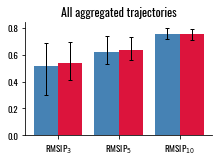

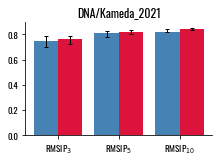

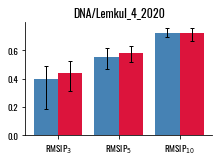

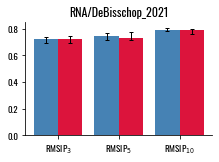

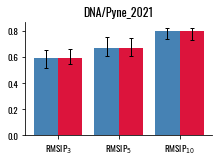

In [1]:
from ElasticNetworkModels import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import json, os
from scipy.stats import mannwhitneyu, ttest_ind, wilcoxon

from matplotlib import rcParams, font_manager

font_path = "./Oswald_font/25844591784.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()

rcParams['font.family'] = font_name
rcParams['lines.linewidth'] = 1.0
rcParams['axes.labelsize'] = 9
rcParams['savefig.dpi'] = 300
rcParams['legend.fancybox'] = False
rcParams['legend.fontsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['patch.linewidth'] = 2.0
rcParams['legend.frameon'] = False

TEST_SYSTEMS = ['DNA/Kameda_2021','DNA/Lemkul_4_2020','RNA/DeBisschop_2021','DNA/Pyne_2021']
MD_testing_path = "MD_testing"
json_file = "analysis_results.json"
data_pca = json.load(open(f'{MD_testing_path}/{json_file}'))

metrics = ["RMSIP_3", "RMSIP_5", "RMSIP_10"]

results = {
    "ENM": {k: [] for k in metrics},
    "edENM": {k: [] for k in metrics},
    "BY_SYSTEM": {system: {"ENM": {}, "edENM": {}} for system in TEST_SYSTEMS}
}

for system in TEST_SYSTEMS:
    for name in ["ENM", "edENM"]:
        for k in ["RMSIP_3", "RMSIP_5", "RMSIP_10"]:
            results["BY_SYSTEM"][system][name][k] = []

overlap_matrix = []
for key in ["RNA","DNA"]:
    for study in data_pca[key]:
        if study['path'] not in TEST_SYSTEMS:
            continue
        for structure in study["enm_structures"]:
            trj_number = int(structure.split('_traj-')[1].split('_')[0])
            window_number = int(structure.split('_window-')[1].split('.')[0])
            ref_eigvecs = np.loadtxt(os.path.join(MD_testing_path,study["path"],f"eigenvectors_traj-{trj_number}_window-{window_number}.dat"))
            for name, model in zip(["ENM","edENM"],[BussiENM,NucleicAcidENM]):
                print(f"Checking {study['path']} | Traj: {trj_number+1} | Window: {window_number+1} | Model: {name}")
                b = model(os.path.join(MD_testing_path,structure))
                b.build_hessian(sparse=False)
                eigvals, v = b.calcModes(sparse=False)
                P_idx = np.array([np.arange(3*i, 3*i+3) for i in np.where(b.nodeAtomNames=="P")[0]]).ravel()
                eigvecs = v[P_idx, :]
                eigvecs = eigvecs / np.linalg.norm(eigvecs, axis=0)
                expl_var = calcExplainedVariance(eigvals)
                o, _ = calcOverlap(enm_vecs=eigvecs, pca_vecs=ref_eigvecs, n_enm=10, n_pca=10)
                overlap_matrix.append(o)
                for n_components in [3,5,10]:
                    results[name][f"RMSIP_{n_components}"].append(calcRMSIP(eigvecs,ref_eigvecs, n_components))
                    results["BY_SYSTEM"][study["path"]][name][f"RMSIP_{n_components}"].append(calcRMSIP(eigvecs,ref_eigvecs, n_components))
                    

fig,ax = plt.subplots(1,1,figsize=(8/2.54,6/2.54))
w = 0.4
print(f"\n### All 4 systems aggregated ###")
for i,k in enumerate(["RMSIP_3", "RMSIP_5", "RMSIP_10"]):
    meanval = np.median(results["ENM"][k])
    q1val = meanval - np.quantile(results["ENM"][k],0.25)
    q3val = np.quantile(results["ENM"][k],0.75) -meanval
    ax.bar(x=i-w/2,height=meanval, yerr=[[q1val],[q3val]],capsize=2,color='steelblue',width=w)
    meanval = np.median(results["edENM"][k])
    q1val = meanval - np.quantile(results["edENM"][k],0.25)
    q3val = np.quantile(results["edENM"][k],0.75) -meanval
    ax.bar(x=i+w/2,height=meanval, yerr=[[q1val],[q3val]],capsize=2,color='crimson',width=w)

ax.set_title("All aggregated trajectories")
ax.set_xticks(np.arange(3))
ax.set_xticklabels([r"RMSIP$_3$", r"RMSIP$_5$", r"RMSIP$_{10}$"])
ax.set_ylim(bottom=0)
sns.despine()
fig.tight_layout()

# test if the differences are significant
for k in ["RMSIP_3", "RMSIP_5", "RMSIP_10"]:
    _, pval = wilcoxon(results["ENM"][k],results["edENM"][k],alternative='two-sided')
    print(f"{k}: p = {pval:.4f} -> significant: {pval < 0.05}")
fig.savefig("Images/PCA_comparison_DNA_RNA.png",dpi=600,facecolor='w')


# do the test also for each separate system and plot corresponding figure
for system in TEST_SYSTEMS:
    fig, ax = plt.subplots(1,1,figsize=(8/2.54,6/2.54))
    w = 0.4
    print(f"\n### System: {system} ###")
    for i, k in enumerate(["RMSIP_3", "RMSIP_5", "RMSIP_10"]):
        enm_vals = results["BY_SYSTEM"][system]["ENM"][k]
        edenm_vals = results["BY_SYSTEM"][system]["edENM"][k]
        if len(enm_vals) == 0 or len(edenm_vals) == 0:
            continue  # skip if no data

        meanval = np.median(enm_vals)
        q1val = meanval - np.quantile(enm_vals,0.25)
        q3val = np.quantile(enm_vals,0.75) - meanval
        ax.bar(x=i-w/2, height=meanval, yerr=[[q1val],[q3val]],capsize=2, color='steelblue', width=w)
        meanval = np.median(edenm_vals)
        q1val = meanval - np.quantile(edenm_vals,0.25)
        q3val = np.quantile(edenm_vals,0.75) - meanval
        ax.bar(x=i+w/2, height=meanval, yerr=[[q1val],[q3val]],capsize=2, color='crimson', width=w)
        _, pval = wilcoxon(enm_vals, edenm_vals, alternative='two-sided')
        print(f"{k}: p = {pval:.4f} -> significant: {pval < 0.05}")

    ax.set_xticks(np.arange(3))
    ax.set_xticklabels([r"RMSIP$_3$", r"RMSIP$_5$", r"RMSIP$_{10}$"])
    ax.set_ylim(bottom=0)
    ax.set_title(system)
    sns.despine()
    fig.tight_layout()
    fig.savefig(f"Images/PCA_comparison_{system.replace('/','_')}.png", dpi=600, facecolor='w')

# Evaluation of edENM performance on DNA- and RNA-only NMR ensembles

Evaluation of edENM for Nucleic_acid_NMR_structures_testing/1AX6.pdb
  → Max overlap (top 3): 0.738 (NM 1, PC 1)
  → Max overlap (top 5): 0.738 (NM 1, PC 1)
  → RMSIP(3): 0.553
  → RMSIP(5): 0.553
  → CSO-3_1: 0.599
  → CSO-5_1: 0.658
Evaluation of ENM for Nucleic_acid_NMR_structures_testing/1AX6.pdb
  → Max overlap (top 3): 0.583 (NM 3, PC 1)
  → Max overlap (top 5): 0.583 (NM 3, PC 1)
  → RMSIP(3): 0.528
  → RMSIP(5): 0.551
  → CSO-3_1: 0.607
  → CSO-5_1: 0.617
Evaluation of edENM for Nucleic_acid_NMR_structures_testing/1BJ2.pdb
  → Max overlap (top 3): 0.621 (NM 1, PC 2)
  → Max overlap (top 5): 0.621 (NM 1, PC 2)
  → RMSIP(3): 0.653
  → RMSIP(5): 0.676
  → CSO-3_1: 0.512
  → CSO-5_1: 0.701
Evaluation of ENM for Nucleic_acid_NMR_structures_testing/1BJ2.pdb
  → Max overlap (top 3): 0.713 (NM 1, PC 2)
  → Max overlap (top 5): 0.713 (NM 1, PC 2)
  → RMSIP(3): 0.690
  → RMSIP(5): 0.712
  → CSO-3_1: 0.507
  → CSO-5_1: 0.749
Evaluation of edENM for Nucleic_acid_NMR_structures_testing/1FYP

Evaluation of ENM for Nucleic_acid_NMR_structures_testing/6H1K.pdb
  → Max overlap (top 3): 0.779 (NM 1, PC 2)
  → Max overlap (top 5): 0.779 (NM 1, PC 2)
  → RMSIP(3): 0.616
  → RMSIP(5): 0.602
  → CSO-3_1: 0.387
  → CSO-5_1: 0.486
Evaluation of edENM for Nucleic_acid_NMR_structures_testing/8S1W.pdb
  → Max overlap (top 3): 0.726 (NM 1, PC 1)
  → Max overlap (top 5): 0.726 (NM 1, PC 1)
  → RMSIP(3): 0.712
  → RMSIP(5): 0.623
  → CSO-3_1: 0.803
  → CSO-5_1: 0.860
Evaluation of ENM for Nucleic_acid_NMR_structures_testing/8S1W.pdb
  → Max overlap (top 3): 0.775 (NM 1, PC 1)
  → Max overlap (top 5): 0.775 (NM 1, PC 1)
  → RMSIP(3): 0.707
  → RMSIP(5): 0.627
  → CSO-3_1: 0.851
  → CSO-5_1: 0.876
Evaluation of edENM for Nucleic_acid_NMR_structures_testing/BtCov/8UYJ.pdb
  → Max overlap (top 3): 0.858 (NM 1, PC 1)
  → Max overlap (top 5): 0.858 (NM 1, PC 1)
  → RMSIP(3): 0.691
  → RMSIP(5): 0.581
  → CSO-3_1: 0.834
  → CSO-5_1: 0.916
Evaluation of ENM for Nucleic_acid_NMR_structures_testing/

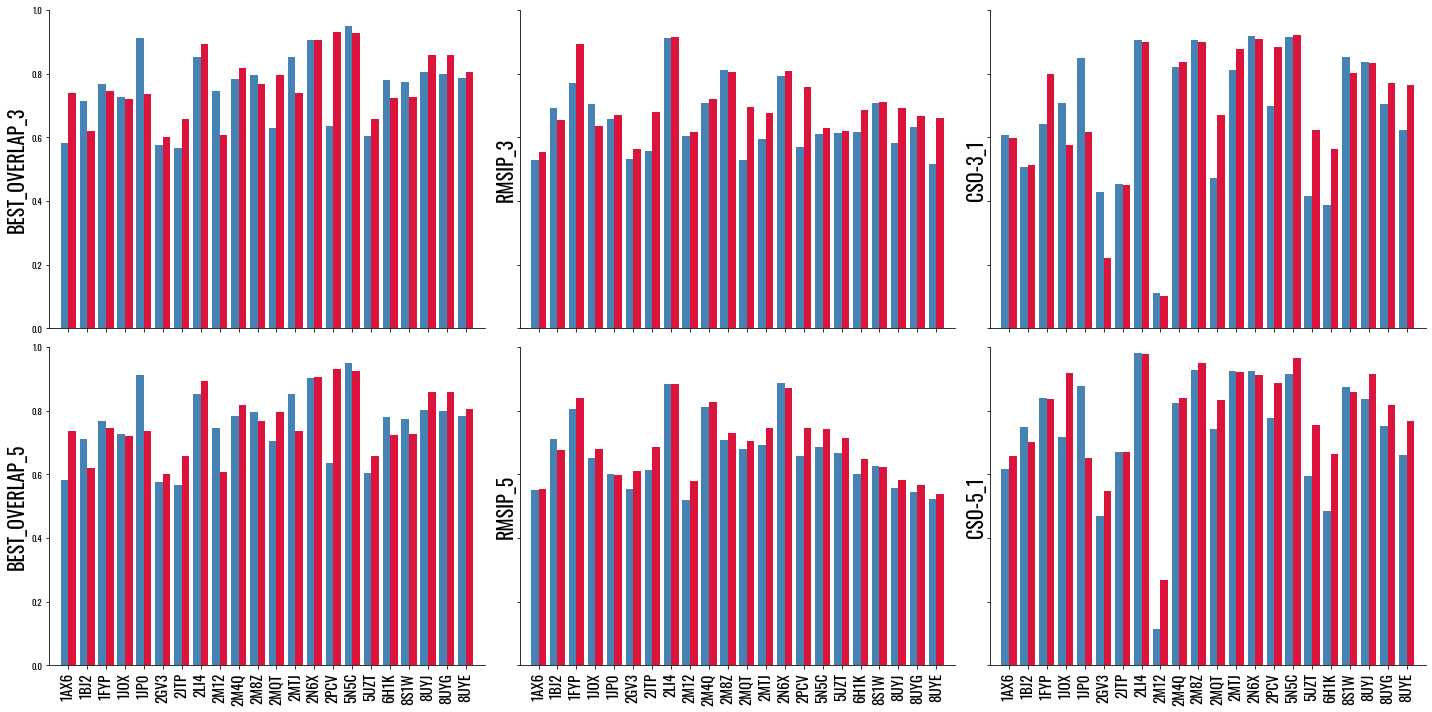

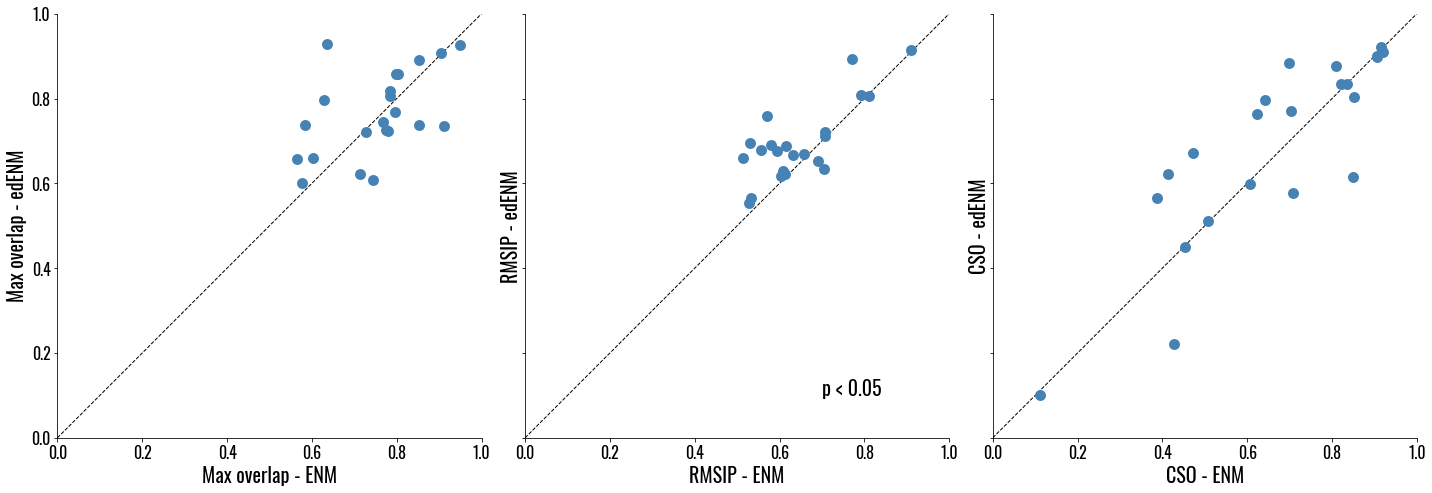

In [5]:
from ElasticNetworkModels import *
from MDAnalysis.analysis.pca import PCA
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import json, os
from scipy.stats import mannwhitneyu, ttest_ind, wilcoxon
import warnings
warnings.filterwarnings('ignore')

from matplotlib import rcParams, font_manager

font_path = "./Oswald_font/25844591784.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()

rcParams['font.family'] = font_name
rcParams['lines.linewidth'] = 1.0
rcParams['axes.labelsize'] = 9
rcParams['savefig.dpi'] = 300
rcParams['legend.fancybox'] = False
rcParams['legend.fontsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['patch.linewidth'] = 2.0
rcParams['legend.frameon'] = False


TEST_SYSTEMS = ["1AX6.pdb", "1BJ2.pdb", "1FYP.pdb", "hairpin/*.pdb", "2GV3.pdb", "2JTP.pdb",
                "2LI4.pdb", "2M12.pdb", "2M4Q.pdb", "2M8Z.pdb", "2MQT.pdb", "2MTJ.pdb", "2N6X.pdb",
                "2PCV.pdb", "5N5C.pdb", "5UZT.pdb", "6H1K.pdb", "8S1W.pdb", "BtCov/*.pdb"]

datapath = "Nucleic_acid_NMR_structures_testing"
metrics = ["RMSIP_3", "RMSIP_5", "BEST_OVERLAP_3", "BEST_OVERLAP_5", "CSO-3_1", "CSO-5_1",'ID']
results = {"ENM": {k:[] for k in metrics}, "edENM": {k:[] for k in metrics}}
for system in TEST_SYSTEMS:
    files = glob(f"{datapath}/{system}")
    ensemble = mda.Universe(files[0],files)
    pca_res = PCA(ensemble,select="name P",align=True).run()
    ref_eigvecs = pca_res.p_components
    for file in files:
        for name, model in zip(["edENM","ENM"],[NucleicAcidENM,BussiENM]):
            b = model(file)
            b.build_hessian(sparse=False)
            eigvals, v = b.calcModes(sparse=False)
            P_idx = np.array([np.arange(3*i, 3*i+3) for i in np.where(b.nodeAtomNames=="P")[0]]).ravel()
            eigvecs = v[P_idx, :]
            eigvecs = eigvecs / np.linalg.norm(eigvecs, axis=0)
            o3, cum_overlap3 = calcOverlap(enm_vecs=eigvecs, pca_vecs=ref_eigvecs, n_enm=3, n_pca=3) 
            idx3 = np.unravel_index(np.argmax(o3[:3, :3]), o3[:3, :3].shape)
            best_nm3, best_pc3 = idx3[0] + 1, idx3[1] + 1
            o5, cum_overlap5 = calcOverlap(enm_vecs=eigvecs, pca_vecs=ref_eigvecs, n_enm=5, n_pca=5) 
            idx5 = np.unravel_index(np.argmax(o5[:5, :5]), o5[:5, :5].shape)
            best_nm5, best_pc5 = idx5[0] + 1, idx5[1] + 1 
            
            results[name]["BEST_OVERLAP_3"].append(o3[idx3])
            results[name]["BEST_OVERLAP_5"].append(o5[idx5])
            results[name]["CSO-3_1"].append(cum_overlap3[0])
            results[name]["CSO-5_1"].append(cum_overlap5[0])
            for n_components in [3,5]:
                results[name][f"RMSIP_{n_components}"].append(calcRMSIP(eigvecs, ref_eigvecs, n_components))
            results[name]["ID"].append(file.split("/")[-1].split(".")[0])
            
            print(f"Evaluation of {name} for {file}")
            print(f"  → Max overlap (top 3): {o3[idx3]:.3f} (NM {best_nm3}, PC {best_pc3})")
            print(f"  → Max overlap (top 5): {o5[idx5]:.3f} (NM {best_nm5}, PC {best_pc5})")
            print(f"  → RMSIP(3): {calcRMSIP(eigvecs, ref_eigvecs, 3):.3f}")
            print(f"  → RMSIP(5): {calcRMSIP(eigvecs, ref_eigvecs, 5):.3f}")
            print(f"  → CSO-3_1: {cum_overlap3[0]:.3f}")
            print(f"  → CSO-5_1: {cum_overlap5[0]:.3f}")
            
summary = []

for model_name in ["ENM", "edENM"]:
    for metric in metrics:
        if metric == "ID":
            continue  # skip IDs, not numeric
        data = np.array(results[model_name][metric])
        mean_val = np.mean(data)
        std_val = np.std(data)
        summary.append({"Model": model_name, "Metric": metric,
                        "Mean": mean_val, "Std": std_val})

summary_df = pd.DataFrame(summary)
print("\n=== Summary of Metrics ===")
print(summary_df)

keys = ["BEST_OVERLAP_3","RMSIP_3","CSO-3_1","BEST_OVERLAP_5","RMSIP_5","CSO-5_1"]
N = len(results["ENM"]["RMSIP_3"])
fig,ax = plt.subplots(2,3,figsize=(20,10),sharex=True,sharey=True)
w = 0.4
for i,key in enumerate(keys):
    ax.ravel()[i].bar(np.arange(N)-w/2,results['ENM'][key],width=w,label="ENM",color='steelblue')
    ax.ravel()[i].bar(np.arange(N)+w/2,results['edENM'][key],width=w,label="edENM",color='crimson')
    ax.ravel()[i].set_xticks(np.arange(N))
    ax.ravel()[i].set_xticklabels(results['edENM']["ID"],rotation=90,size=15)
    ax.ravel()[i].set_ylabel(key,size=20)
    ax.ravel()[i].set_xlim(-1,N)
    ax.ravel()[i].set_ylim(0,1)
    sns.despine()
    fig.tight_layout()
    fig.savefig(f"Images/Comparison_NMs_PCs_NMR_testing_set_nucleic_acids.png", dpi=600, facecolor='w')
    
metrics = ["BEST_OVERLAP_3","RMSIP_3","CSO-3_1"]
fig,ax = plt.subplots(1,3,figsize=(20,10),sharex=True,sharey=True)
for i,metric in enumerate(metrics):
    _, p = wilcoxon(results['ENM'][metric], results['edENM'][metric],alternative='less')
    print(f"{metric} - edENM > ENM: p={p:.4f}")
    ax.ravel()[i].scatter(results['ENM'][metric], results['edENM'][metric],s=80,zorder=2,color='steelblue')
    ax.ravel()[i].plot([0,1],[0,1],'k--',zorder=1)
    ax.ravel()[i].set_xlim(0,1)
    ax.ravel()[i].set_ylim(0,1)
    if metric == "BEST_OVERLAP_3":
        labeling = "Max overlap"
    if metric == "RMSIP_3":
        labeling = "RMSIP"
    if metric == "CSO-3_1":
        labeling = "CSO"
    ax.ravel()[i].set_xlabel(f"{labeling} - ENM",size=20)
    ax.ravel()[i].set_ylabel(f"{labeling} - edENM",size=20)
    ax.ravel()[i].set_aspect('equal')
    ax.ravel()[i].tick_params(axis='both', which='major', labelsize=16)
    if p < 0.05:
        ax.ravel()[i].text(0.7,0.1,f"p < 0.05",size=20)
    sns.despine()
    fig.tight_layout()
    fig.savefig("Images/Dataset_comparison_NM_PC_NMR_testing_set_nucleic_acids.png",dpi=600,facecolor='w')

Results PCA of the NMR ensemble
Collectivity for PC modes: 0.62-0.63-0.62-0.68-0.74
Explained variance for PC modes: 0.67-0.12-0.07-0.05-0.03
Number of PC modes explaining 90% of variance: 4


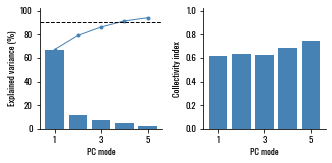

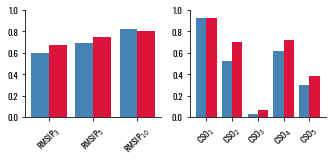

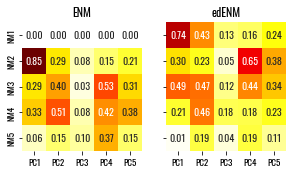

In [2]:
from ElasticNetworkModels import *
from MDAnalysis.analysis.pca import PCA
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import json, os
from scipy.stats import mannwhitneyu, ttest_ind, wilcoxon
import warnings
warnings.filterwarnings('ignore')

from matplotlib import rcParams, font_manager

font_path = "./Oswald_font/25844591784.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()

rcParams['font.family'] = font_name
rcParams['lines.linewidth'] = 1.0
rcParams['axes.labelsize'] = 9
rcParams['savefig.dpi'] = 300
rcParams['legend.fancybox'] = False
rcParams['legend.fontsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['patch.linewidth'] = 2.0
rcParams['legend.frameon'] = False

if not os.path.isdir("movies"):
    os.mkdir("movies")

files = glob("Nucleic_acid_NMR_structures_testing/2MTJ.pdb") # define here the PDB of the NMR ensemble
# files = glob("Nucleic_acid_NMR_structures_testing/BtCov/*.pdb") # Use this for the whole set of BtCov PDBs
# files = glob("Nucleic_acid_NMR_structures_testing/hairpin/*.pdb") # Use this for the whole set of hairpin PDBs

imagefile_pc = "Images/PCA_2MTJ.png" # define here name of the figure with PCA results
imagefile_rmsip_cso = "Images/RMSIP_CSO_2MTJ.png" # define here name of the figure with RMSIP and CSO results
imagefile_overlaps = "Images/overlap_matrix_2MTJ.png" # define here name of the figure with overlap matrix

ensemble = mda.Universe(files[0],files)
pca_res = PCA(ensemble,select="name P",align=True).run()
ref_eigvecs = pca_res.p_components
n_enm =5

# Collectivity and explained variance of the ensemble
print("Results PCA of the NMR ensemble")
collectivities = calcCollectivity(ref_eigvecs)
print(f"Collectivity for PC modes: {'-'.join([f'{c:.2f}' for c in collectivities[:5]])}")
expl_variance = pca_res.cumulated_variance - np.concatenate([[0],pca_res.cumulated_variance[:-1]])
print(f"Explained variance for PC modes: {'-'.join([f'{c:.2f}' for c in expl_variance[:5]])}")
N = np.where(pca_res.cumulated_variance > 0.9)[0][0]+1
print(f"Number of PC modes explaining 90% of variance: {N}")
fig, ax = plt.subplots(1,2,figsize=(12/2.54,6/2.54),sharex=True)
ax[0].bar(np.arange(1,6),expl_variance[:5]*100,color='steelblue')
ax[0].plot(np.arange(1,6),pca_res.cumulated_variance[:5]*100,color='steelblue',marker='o',markersize=3)
ax[0].axhline(90,linestyle='--',color='black')
ax[0].set_xlabel("PC mode")
ax[0].set_xticks(np.arange(1,6,step=2))
ax[0].set_ylabel("Explained variance (%)")
ax[0].set_ylim(0,102)
ax[1].bar(np.arange(1,6),collectivities[:5],color='steelblue')
ax[1].set_xlabel("PC mode")
ax[1].set_xticks(np.arange(1,6,step=2))
ax[1].set_ylabel("Collectivity index")
ax[1].set_ylim(0,1.02)
sns.despine()
fig.tight_layout()
fig.savefig(imagefile_pc,dpi=600,facecolor='w')

# Comparison of PCA to ENM and edENM
n_modes_pca = 5
metrics = ["RMSIP_3", "RMSIP_5", "RMSIP_10"]
results = {"ENM": {k:[] for k in metrics}, "edENM": {k:[] for k in metrics}}
csos = {"ENM":[], "edENM":[]}
ovelaps = {"ENM":[], "edENM":[]}
nm_amplitude = 30 # Change here to modify amplitude of the computed motion 
for structure in files:
    for name, model in zip(["edENM","ENM"],[NucleicAcidENM,BussiENM]):
        b = model(structure)
        b.build_hessian(sparse=False)
        eigvals, v = b.calcModes(sparse=False)
        P_idx = np.array([np.arange(3*i, 3*i+3) for i in np.where(b.nodeAtomNames=="P")[0]]).ravel()
        eigvecs = v[P_idx, :]
        eigvecs = eigvecs / np.linalg.norm(eigvecs, axis=0)
        collectivities = calcCollectivity(eigvecs)
        for n_components in [3,5,10]:
            results[name][f"RMSIP_{n_components}"].append(calcRMSIP(eigvecs, ref_eigvecs, n_components))
        o, cum_overlap = calcOverlap(enm_vecs=eigvecs, pca_vecs=ref_eigvecs, n_enm=n_enm, n_pca=n_modes_pca)
        ovelaps[name].append(o)
        csos[name].append(cum_overlap)
        makeTraj(v,structure,f"movies/{structure.split('/')[-1].split('.')[0]}_{name}.pdb",steps=5,ampl=nm_amplitude,modes=[0,1],selection="name P C2 C1'")

fig,ax = plt.subplots(1,2,figsize=(12/2.54,6/2.54))
w = 0.4
for name in ["ENM","edENM"]:
    # if it is a list of list, stack them and median
    if len(csos[name])>1:
        meanval = np.median(np.vstack(csos[name]),axis=0)
        q1val = meanval - np.quantile(np.vstack(csos[name]),0.25,axis=0)
        q3val = np.quantile(np.vstack(csos[name]),0.75,axis=0) -meanval
        ax[1].bar(np.arange(1,n_modes_pca+1)+w/2 if name=="edENM" else np.arange(1,n_modes_pca+1)-w/2,meanval,yerr=[q1val,q3val],
                  width=w,label=name,color='steelblue' if name=="ENM" else 'crimson',capsize=2)
    elif isinstance(csos[name][0],np.ndarray):
        csos[name] = csos[name][0]
        ax[1].bar(np.arange(1,n_modes_pca+1)+w/2 if name=="edENM" else np.arange(1,n_modes_pca+1)-w/2,csos[name],width=w,
                  label=name,color='steelblue' if name=="ENM" else 'crimson')
    else:
        csos[name] = np.array(csos[name])
        ax[1].bar(np.arange(1,n_modes_pca+1)+w/2 if name=="edENM" else np.arange(1,n_modes_pca+1)-w/2,csos[name],width=w,
                  label=name,color='steelblue' if name=="ENM" else 'crimson')
ax[1].set_xticks(np.arange(1,n_modes_pca+1))
ax[1].set_xticklabels([r"CSO$_1$", r"CSO$_2$", r"CSO$_3$", r"CSO$_4$", r"CSO$_5$"],rotation=45)
ax[1].set_ylim(0,1)

for x,key in zip([-w/2,+w/2],results):
    for i,metric in enumerate(results[key]):
        if len(results[key][metric])>1:
            results[key][metric] = np.array(results[key][metric])
            meanval = np.median(results[key][metric])
            q1val = meanval - np.quantile(results[key][metric],0.25)
            q3val = np.quantile(results[key][metric],0.75) -meanval
            ax[0].bar(x+i,meanval, yerr=[[q1val],[q3val]],capsize=2,color='steelblue' if key=="ENM" else 'crimson',width=w)
        else:
            ax[0].bar(x+i,results[key][metric],color='steelblue' if key=="ENM" else 'crimson',width=w)
ax[0].set_xticks(np.arange(3))
ax[0].set_xticklabels([r"RMSIP$_3$", r"RMSIP$_5$", r"RMSIP$_{10}$"],rotation=45)
ax[0].set_ylim(0,1)
sns.despine()
fig.tight_layout()
fig.savefig(imagefile_rmsip_cso,dpi=600,facecolor='w')

# Heatmap of the overlaps
i = 0 # For Hairpin and BtCov change this index to i = 1 or i = 1, 2 to see overlap metrics for the other PDB structures
fig, ax = plt.subplots(1,2,figsize=(12/2.54,6/2.54),sharex=True,sharey=True)
sns.heatmap(ovelaps["ENM"][i][:5,:5],annot=True,fmt=".2f",cmap='hot_r',cbar=False,xticklabels=[f"PC{i}" for i in range(1,6)],
            ax = ax[0],vmax=1,vmin=0);
sns.heatmap(ovelaps["edENM"][i][:5,:5],annot=True,fmt=".2f",cmap='hot_r',cbar=False,xticklabels=[f"PC{i}" for i in range(1,6)],
            yticklabels=[f"ENM{i}" for i in range(1,6)], ax = ax[1],vmax=1,vmin=0);
ax[0].set_title("ENM")
ax[1].set_title("edENM");
ax[1].set_yticklabels([f"NM{i}" for i in range(1,6)],rotation=0)
fig.savefig(imagefile_overlaps,dpi=600,facecolor='w')

# Parameter refinement for protein-nucleic acid edENM

Parameter set 1/72: C_HIGH=15, C_LOW=30, P_HIGH=1.9, CUTOFF=8
Parameter set 2/72: C_HIGH=15, C_LOW=30, P_HIGH=1.9, CUTOFF=9
Parameter set 3/72: C_HIGH=15, C_LOW=30, P_HIGH=2.0, CUTOFF=8
Parameter set 4/72: C_HIGH=15, C_LOW=30, P_HIGH=2.0, CUTOFF=9
Parameter set 5/72: C_HIGH=15, C_LOW=30, P_HIGH=2.1, CUTOFF=8
Parameter set 6/72: C_HIGH=15, C_LOW=30, P_HIGH=2.1, CUTOFF=9
Parameter set 7/72: C_HIGH=15, C_LOW=30, P_HIGH=2.2, CUTOFF=8
Parameter set 8/72: C_HIGH=15, C_LOW=30, P_HIGH=2.2, CUTOFF=9
Parameter set 9/72: C_HIGH=15, C_LOW=35, P_HIGH=1.9, CUTOFF=8
Parameter set 10/72: C_HIGH=15, C_LOW=35, P_HIGH=1.9, CUTOFF=9
Parameter set 11/72: C_HIGH=15, C_LOW=35, P_HIGH=2.0, CUTOFF=8
Parameter set 12/72: C_HIGH=15, C_LOW=35, P_HIGH=2.0, CUTOFF=9
Parameter set 13/72: C_HIGH=15, C_LOW=35, P_HIGH=2.1, CUTOFF=8
Parameter set 14/72: C_HIGH=15, C_LOW=35, P_HIGH=2.1, CUTOFF=9
Parameter set 15/72: C_HIGH=15, C_LOW=35, P_HIGH=2.2, CUTOFF=8
Parameter set 16/72: C_HIGH=15, C_LOW=35, P_HIGH=2.2, CUTOFF=9
P

,CUTOFF,C_HIGH,C_LOW,P_HIGH,RMSIP-Q1,RMSIP-MED,RMSIP-Q3,MAX_OVERLAP-Q1,MAX_OVERLAP-MED,MAX_OVERLAP-Q3,CSO-3_1-Q1,CSO-3_1-MED,CSO-3_1-Q3
70,8,25,40,2.2,0.431,0.513,0.567,0.483,0.619,0.694,0.206,0.421,0.585
54,8,25,30,2.2,0.420,0.516,0.567,0.486,0.620,0.689,0.211,0.398,0.593
26,8,20,30,2.0,0.411,0.508,0.570,0.487,0.617,0.687,0.214,0.397,0.596
0,8,15,30,1.9,0.410,0.494,0.569,0.488,0.615,0.683,0.216,0.401,0.595
16,8,15,40,1.9,0.421,0.493,0.567,0.452,0.624,0.687,0.211,0.424,0.592
1,9,15,30,1.9,0.418,0.491,0.557,0.444,0.596,0.720,0.217,0.344,0.572
17,9,15,40,1.9,0.416,0.490,0.556,0.446,0.601,0.712,0.230,0.345,0.568
16,8,15,40,1.9,0.421,0.493,0.567,0.452,0.624,0.687,0.211,0.424,0.592
28,8,20,30,2.1,0.412,0.509,0.569,0.487,0.617,0.687,0.213,0.397,0.597


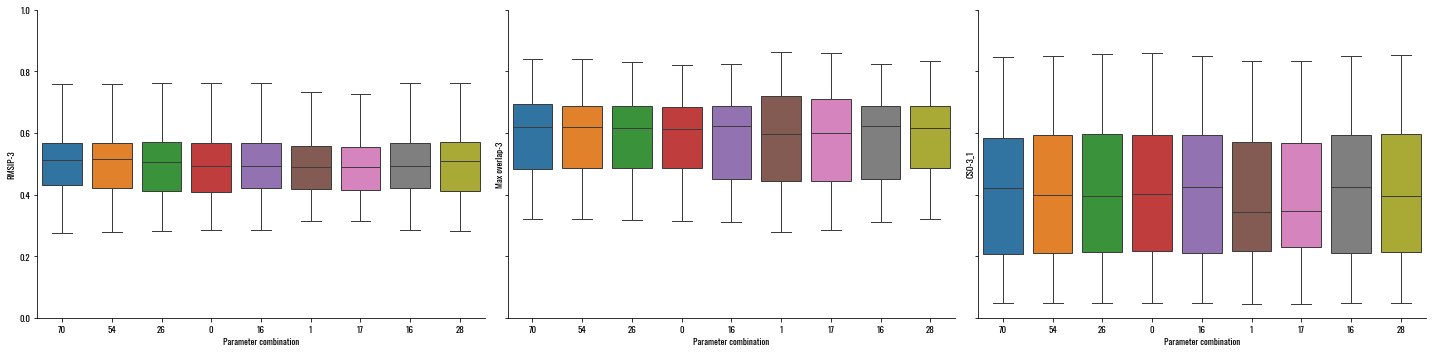

In [13]:
from ElasticNetworkModels import NormalModeAnalysis2, calcOverlap, calcRMSIP, edENM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from MDAnalysis.analysis.pca import PCA
import MDAnalysis as mda
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

from matplotlib import rcParams, font_manager

font_path = "./Oswald_font/25844591784.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()

rcParams['font.family'] = font_name
rcParams['lines.linewidth'] = 1.0
rcParams['axes.labelsize'] = 9
rcParams['savefig.dpi'] = 300
rcParams['legend.fancybox'] = False
rcParams['legend.fontsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['patch.linewidth'] = 2.0
rcParams['legend.frameon'] = False

pdb_ids = ["1AHD", "1AUD", "1F6U", "1FJE", "1FNX", "1ULL", "2KEK", "2KM8", "2K1N", "2K7F", "2LT7", "2ME6",
           "2MF0", "2MKK", "2MRU", "2N3O", "2N82", "2OEH", "6GBM", "6WLH", "7WNR"]

results = defaultdict(lambda: defaultdict(list))
c_high_list = [15,20,25]
c_low_list = [30,35,40]
p_high_list = [1.9,2.0,2.1,2.2]
cutoff_list = [8,9]
parameters_list = [(c_high,c_low,p_high,cutoff) for c_high in c_high_list for c_low in c_low_list for p_high in p_high_list for cutoff in cutoff_list]

for i,par_set in enumerate(parameters_list):
    C_HIGH, C_LOW, P_HIGH, CUTOFF = par_set
    print(f"Parameter set {i+1}/{len(parameters_list)}: C_HIGH={C_HIGH}, C_LOW={C_LOW}, P_HIGH={P_HIGH}, CUTOFF={CUTOFF}")
    for pdbid in pdb_ids:
        ensemble = mda.Universe(f"Complexes_NMR_structures_optimization/{pdbid}.pdb")
        pca_res = PCA(ensemble,select="name CA P",align=True).run()
        ref_eigvecs = pca_res.p_components

        tmpfile = f"Complexes_NMR_structures_optimization/{pdbid}_tmp.pdb"
        mod_id = pdbid+"_tmp"
        # find the frame of the ensemble with the lowest RMSD to the mean
        ref_coordinates = np.stack([a.position for a in ensemble.select_atoms("name CA P")],axis=0).mean(axis=0)
        rmsds = []
        for _ in ensemble.trajectory:
            rmsds.append(np.sqrt(np.mean((ensemble.select_atoms("name CA P").positions - ref_coordinates)**2)))
        ensemble.trajectory[np.argmin(rmsds)]
        # print(f"Frame with lowest RMSD: {int(np.argmin(rmsds))}")
        ensemble.atoms.write(tmpfile)
            
        model = NormalModeAnalysis2(cutoff_inter=CUTOFF,C_high=C_HIGH,C_low=C_LOW,p_high=P_HIGH)
        model.extract_ca_coordinates_and_masses(tmpfile)
        model.construct_hessian(mod_id,build_gamma=True)
        model.solve_eigenproblem(mod_id)
        model.compute_vectors_for_NMA(mod_id,num_modes=5)
        os.remove(tmpfile)

        eigens = []
        for mode, mode_eigenvecs in model.eigenvecs_reshaped[mod_id].items():
                # get only indices for C-alpha atoms and P atoms
                mode_eigenvecs = mode_eigenvecs[(np.array(model.coord_dict[mod_id][3]) == "P")|(np.array(model.coord_dict[mod_id][3]) == "CA")].ravel()
                eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
        eigens = np.column_stack(eigens)
        o, cum_overlap = calcOverlap(enm_vecs=eigens, pca_vecs=ref_eigvecs, n_enm=3, n_pca=3)
        rmsip = calcRMSIP(eigens, ref_eigvecs, 3)
        results["RMSIP_3"][i].append(rmsip)
        results["BEST_OVERLAP_3"][i].append(np.max(o))
        results["CSO-3_1"][i].append(cum_overlap[0])
        results["CSO-3_2"][i].append(cum_overlap[1])
        results["CSO-3_3"][i].append(cum_overlap[2])
    for key, value in results.items():
        results[key][i] = np.array(value[i])

all_res= {"CUTOFF": [], "C_HIGH": [], "C_LOW": [], "P_HIGH": [],
            "RMSIP-Q1": [], "RMSIP-MED": [], "RMSIP-Q3": [],
            "MAX_OVERLAP-Q1": [], "MAX_OVERLAP-MED": [], "MAX_OVERLAP-Q3": [],
            "CSO-3_1-Q1": [],"CSO-3_1-MED": [], "CSO-3_1-Q3": []}

for i in range(len(parameters_list)):
    all_res["CUTOFF"].append(parameters_list[i][3])
    all_res["C_HIGH"].append(parameters_list[i][0])
    all_res["C_LOW"].append(parameters_list[i][1])
    all_res["P_HIGH"].append(parameters_list[i][2])
    all_res["RMSIP-Q1"].append(np.quantile(results["RMSIP_3"][i],0.25).round(3))
    all_res["RMSIP-MED"].append(np.median(results["RMSIP_3"][i]).round(3))
    all_res["RMSIP-Q3"].append(np.quantile(results["RMSIP_3"][i],0.75).round(3))
    all_res["MAX_OVERLAP-Q1"].append(np.quantile(results["BEST_OVERLAP_3"][i],0.25).round(3))
    all_res["MAX_OVERLAP-MED"].append(np.median(results["BEST_OVERLAP_3"][i]).round(3))
    all_res["MAX_OVERLAP-Q3"].append(np.quantile(results["BEST_OVERLAP_3"][i],0.75).round(3))
    all_res["CSO-3_1-Q1"].append(np.quantile(results["CSO-3_1"][i],0.25).round(3))
    all_res["CSO-3_1-MED"].append(np.median(results["CSO-3_1"][i]).round(3))
    all_res["CSO-3_1-Q3"].append(np.quantile(results["CSO-3_1"][i],0.75).round(3))

all_res = pd.DataFrame(all_res)        

idxs = [all_res.idxmax()["RMSIP-Q1"],all_res.idxmax()["RMSIP-MED"],all_res.idxmax()["RMSIP-Q3"],
        all_res.idxmax()["MAX_OVERLAP-Q1"],all_res.idxmax()["MAX_OVERLAP-MED"],all_res.idxmax()["MAX_OVERLAP-Q3"],
        all_res.idxmax()["CSO-3_1-Q1"],all_res.idxmax()["CSO-3_1-MED"],all_res.idxmax()["CSO-3_1-Q3"],]
rmsip_medians = all_res.loc[idxs,"RMSIP-MED"]
max_overlap_medians = all_res.loc[idxs,"MAX_OVERLAP-MED"]
cso_medians = all_res.loc[idxs,"CSO-3_1-MED"]
rmsip_yerrs = [rmsip_medians - all_res.loc[idxs,"RMSIP-Q1"], all_res.loc[idxs,"RMSIP-Q3"] - rmsip_medians]
max_overlap_yerrs = [max_overlap_medians - all_res.loc[idxs,"MAX_OVERLAP-Q1"], all_res.loc[idxs,"MAX_OVERLAP-Q3"] - max_overlap_medians]
cso_yerrs = [cso_medians - all_res.loc[idxs,"CSO-3_1-Q1"], all_res.loc[idxs,"CSO-3_1-Q3"] - cso_medians]

fig, ax = plt.subplots(1,3,figsize=(20,5),sharex=True,sharey=True)
data_to_plot = {i: results["RMSIP_3"][k] for i,k in enumerate(idxs)}
sns.boxplot(data=pd.DataFrame(data_to_plot),ax=ax[0])
data_to_plot = {i: results["BEST_OVERLAP_3"][k] for i,k in enumerate(idxs)}
sns.boxplot(data=pd.DataFrame(data_to_plot),ax=ax[1])
data_to_plot = {i: results["CSO-3_1"][k] for i,k in enumerate(idxs)}
sns.boxplot(data=pd.DataFrame(data_to_plot),ax=ax[2])

ax[0].set_xlabel("Parameter combination")
ax[1].set_xlabel("Parameter combination")
ax[2].set_xlabel("Parameter combination")
ax[0].set_ylabel("RMSIP-3")
ax[1].set_ylabel("Max overlap-3")
ax[2].set_ylabel("CSO-3_1")
ax[0].set_ylim(0,1)
ax[0].set_xticklabels(idxs)
sns.despine()
fig.tight_layout()

all_res.iloc[idxs]

In [14]:
print("Optimal (best median RMSIP_3):", parameters_list[all_res.idxmax()["RMSIP-MED"]])

Optimal (best median RMSIP_3): (25, 30, 2.2, 8)


In [15]:
# Fixing optimal parameters as the ones that maximize median values of RMSIP-3!
optimal_cutoff = 8
optimal_p_high = 2.2
optimal_C_high = 25
optimal_C_low = 30

# Protein-nucleic acid edENM: evaluation of performance on MD test set

In [3]:
from ElasticNetworkModels import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import json, os
from scipy.stats import mannwhitneyu, ttest_ind, wilcoxon

from matplotlib import rcParams, font_manager

font_path = "./Oswald_font/25844591784.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()

rcParams['font.family'] = font_name
rcParams['lines.linewidth'] = 1.0
rcParams['axes.labelsize'] = 9
rcParams['savefig.dpi'] = 300
rcParams['legend.fancybox'] = False
rcParams['legend.fontsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['patch.linewidth'] = 2.0
rcParams['legend.frameon'] = False

TEST_SYSTEMS = ['Complex/Kameda_2019', 'Complex/Bochicchio_1_2018','Complex/Sekulovski_2023']

MD_testing_path = "MD_testing"
json_file = "analysis_results.json"
data_pca = json.load(open(f'{MD_testing_path}/{json_file}'))

metrics = ["RMSIP_3", "RMSIP_5", "RMSIP_10"]

results = {
    "ENM": {k: [] for k in metrics},
    "edENM": {k: [] for k in metrics},
    "edProt": {k: [] for k in metrics},
    "BY_SYSTEM": {system: {"ENM": {}, "edENM": {}, "edProt": {}} for system in TEST_SYSTEMS}
}

for system in TEST_SYSTEMS:
    for name in ["ENM", "edENM", "edProt"]:
        for k in ["RMSIP_3", "RMSIP_5", "RMSIP_10"]:
            results["BY_SYSTEM"][system][name][k] = []
            
optimal_cutoff = 8
optimal_p_high = 2.2
optimal_C_high = 25
optimal_C_low = 30            

key = "Complex"
for study in data_pca[key]:
    if study['path'] not in TEST_SYSTEMS:
        continue
    for structure in study["enm_structures"]:
        trj_number = int(structure.split('_traj-')[1].split('_')[0])
        window_number = int(structure.split('_window-')[1].split('.')[0])
        ref_eigvecs = np.loadtxt(os.path.join(MD_testing_path,study["path"],f"eigenvectors_traj-{trj_number}_window-{window_number}.dat"))
        for name, model_type in zip(["ENM","edENM","edProt"],[classicENM,edENM,classicENM]):
            print(f"Checking {study['path']} | Traj: {trj_number+1} | Window: {window_number+1} | Model: {name}")
            if name == "edENM":
                model = model_type(cutoff_inter=optimal_cutoff,C_high=optimal_C_high,C_low=optimal_C_low,p_high=optimal_p_high)
            else:
                model = model_type()
            model.extract_ca_coordinates_and_masses(f"{MD_testing_path}/{structure}")
            pdbid = structure.split("/")[-1].split(".")[0]
            if name == "edENM":
                model.construct_hessian(pdbid, build_gamma=True)
            else:
                if name == "ENM":
                    model.construct_hessian(pdbid, edProt=False)
                else:
                    model.construct_hessian(pdbid, edProt=True)  
            model.solve_eigenproblem(pdbid)
            model.compute_vectors_for_NMA(pdbid,num_modes=10)
            eigvecs = model.eigenvectors[pdbid]
            eigvals = model.eigenvalues[pdbid]
            indices = np.where((np.array(model.coord_dict[pdbid][3]) == "P")|(np.array(model.coord_dict[pdbid][3]) == "CA"))[0]
            indices = np.array([np.arange(3*i, 3*i+3) for i in indices]).ravel()
            enm_eigs = eigvecs[indices,:]
            enm_eigs /= np.linalg.norm(enm_eigs, axis=0)            
            o, _ = calcOverlap(enm_vecs=enm_eigs,pca_vecs=ref_eigvecs,n_enm=10, n_pca=10)
            for n_components in [3,5,10]:
                results[name][f"RMSIP_{n_components}"].append(calcRMSIP(enm_eigs, ref_eigvecs, n_components))
                results["BY_SYSTEM"][study["path"]][name][f"RMSIP_{n_components}"].append(calcRMSIP(enm_eigs, ref_eigvecs, n_components))
                
fig,ax = plt.subplots(1,1,figsize=(8/2.54,6/2.54))
w = 0.2
print(f"\n### All 3 systems aggregated ###")
for i,k in enumerate(["RMSIP_3", "RMSIP_5", "RMSIP_10"]):
    meanval = np.median(results["ENM"][k])
    q1val = meanval - np.quantile(results["ENM"][k],0.25)
    q3val = np.quantile(results["ENM"][k],0.75) -meanval
    ax.bar(x=i-w,height=meanval, yerr=[[q1val],[q3val]],capsize=2,color='steelblue',width=w)
    meanval = np.median(results["edENM"][k])
    q1val = meanval - np.quantile(results["edENM"][k],0.25)
    q3val = np.quantile(results["edENM"][k],0.75) -meanval
    ax.bar(x=i,height=meanval, yerr=[[q1val],[q3val]],capsize=2,color='crimson',width=w)
    meanval = np.median(results["edProt"][k])
    q1val = meanval - np.quantile(results["edProt"][k],0.25)
    q3val = np.quantile(results["edProt"][k],0.75) -meanval
    ax.bar(x=i+w,height=meanval, yerr=[[q1val],[q3val]],capsize=2,color='darkgreen',width=w)

ax.set_title("All aggregated trajectories")
ax.set_xticks(np.arange(3))
ax.set_xticklabels([r"RMSIP$_3$", r"RMSIP$_5$", r"RMSIP$_{10}$"])
ax.set_ylim(bottom=0)
sns.despine()
fig.tight_layout()

# test if the differences are significant
for k in ["RMSIP_3", "RMSIP_5", "RMSIP_10"]:
    _, pval = wilcoxon(results["ENM"][k],results["edENM"][k],alternative='two-sided')
    print(f"{k}: ENM vs edENM - p = {pval:.6f} -> significant: {pval < 0.05}")
    _, pval = wilcoxon(results["edENM"][k],results["edProt"][k],alternative='two-sided')
    print(f"{k}: edENM vs edProt - p = {pval:.6f} -> significant: {pval < 0.05}")
    _, pval = wilcoxon(results["ENM"][k],results["edProt"][k],alternative='two-sided')
    print(f"{k}: ENM vs edProt - p = {pval:.6f} -> significant: {pval < 0.05}")
fig.savefig("Images/PCA_comparison_Complex.png",dpi=600,facecolor='w')

# do the test also for each separate system and plot corresponding figure
for system in TEST_SYSTEMS:
    fig, ax = plt.subplots(1,1,figsize=(8/2.54,6/2.54))
    print(f"\n### System: {system} ###")
    for i, k in enumerate(["RMSIP_3", "RMSIP_5", "RMSIP_10"]):
        enm_vals = results["BY_SYSTEM"][system]["ENM"][k]
        edenm_vals = results["BY_SYSTEM"][system]["edENM"][k]
        edprot_vals = results["BY_SYSTEM"][system]["edProt"][k]
        if len(enm_vals) == 0 or len(edenm_vals) == 0 or len(edprot_vals) == 0:
            continue  # skip if no data

        meanval = np.median(enm_vals)
        q1val = meanval - np.quantile(enm_vals,0.25)
        q3val = np.quantile(enm_vals,0.75) - meanval
        ax.bar(x=i-w, height=meanval, yerr=[[q1val],[q3val]],capsize=2, color='steelblue', width=w)
        meanval = np.median(edenm_vals)
        q1val = meanval - np.quantile(edenm_vals,0.25)
        q3val = np.quantile(edenm_vals,0.75) - meanval
        ax.bar(x=i, height=meanval, yerr=[[q1val],[q3val]],capsize=2, color='crimson', width=w)
        meanval = np.median(edprot_vals)
        q1val = meanval - np.quantile(edprot_vals,0.25)
        q3val = np.quantile(edprot_vals,0.75) - meanval
        ax.bar(x=i+w, height=meanval, yerr=[[q1val],[q3val]],capsize=2, color='darkgreen', width=w)
        _, pval = wilcoxon(enm_vals, edenm_vals, alternative='two-sided')
        print(f"{k}: ENM vs edENM p = {pval:.6f} -> significant: {pval < 0.05}")
        _, pval = wilcoxon(edenm_vals, edprot_vals, alternative='two-sided')
        print(f"{k}: edENM vs edProt p = {pval:.6f} -> significant: {pval < 0.05}")
        _, pval = wilcoxon(enm_vals, edprot_vals, alternative='two-sided')
        print(f"{k}: ENM vs edProt p = {pval:.6f} -> significant: {pval < 0.05}")
        

    ax.set_xticks(np.arange(3))
    ax.set_xticklabels([r"RMSIP$_3$", r"RMSIP$_5$", r"RMSIP$_{10}$"])
    ax.set_ylim(bottom=0)
    ax.set_title(system)
    sns.despine()
    fig.tight_layout()
    fig.savefig(f"Images/PCA_comparison_{system.replace('/','_')}.png", dpi=600, facecolor='w')

FileNotFoundError: MD_testing/Complex/Bochicchio_1_2018/eigenvectors_traj-0_window-0.dat not found.

# Evaluation of edENM performance on NMR of protein-nucleic acid systems

Running ENM comparisons (edENM, classic ENM, edProt) for protein-nucleic acid NMRs
Processing 1AHD...
	ENM
		RMSIP = 0.415
		CSO = [0.09329524 0.32968838 0.09285631]
		Max overlap = 0.551 (NM 2, PC 2)
	edENM
		RMSIP = 0.393
		CSO = [0.24845429 0.11983811 0.09533035]
		Max overlap = 0.408 (NM 2, PC 1)
	edProt
		RMSIP = 0.425
		CSO = [0.1342352  0.24541007 0.16245349]
		Max overlap = 0.457 (NM 2, PC 2)
Processing 1AUD...
	ENM
		RMSIP = 0.674
		CSO = [0.53203383 0.59713099 0.23402504]
		Max overlap = 0.717 (NM 1, PC 2)
	edENM
		RMSIP = 0.555
		CSO = [0.42228499 0.10108993 0.40072082]
		Max overlap = 0.622 (NM 1, PC 1)
	edProt
		RMSIP = 0.659
		CSO = [0.4901127  0.58767863 0.22698371]
		Max overlap = 0.714 (NM 1, PC 2)
Processing 1F6U...
	ENM
		RMSIP = 0.300
		CSO = [0.04564159 0.19054618 0.03443264]
		Max overlap = 0.419 (NM 2, PC 2)
	edENM
		RMSIP = 0.567
		CSO = [0.16608125 0.33659574 0.46160855]
		Max overlap = 0.628 (NM 2, PC 3)
	edProt
		RMSIP = 0.561
		CSO = [0.06863777 0.4251338  0

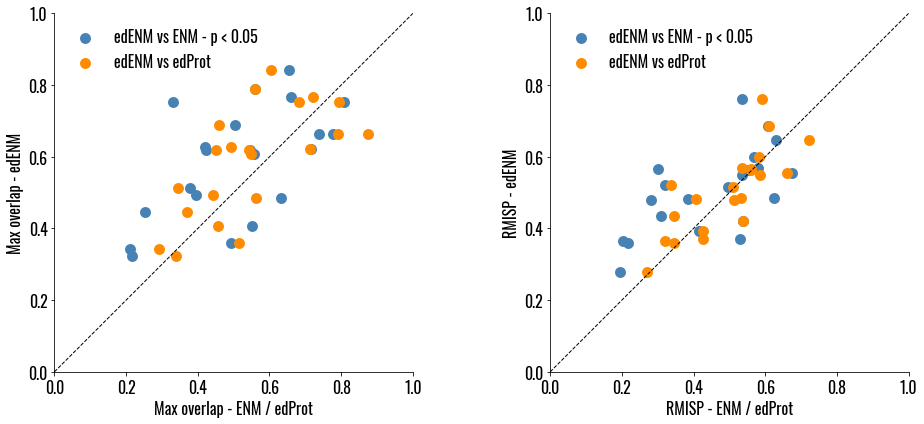

In [5]:
from ElasticNetworkModels import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from MDAnalysis.analysis.pca import PCA
import MDAnalysis as mda
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict
from scipy.stats import wilcoxon

from matplotlib import rcParams, font_manager

font_path = "./Oswald_font/25844591784.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()

rcParams['font.family'] = font_name
rcParams['lines.linewidth'] = 1.0
rcParams['axes.labelsize'] = 16
rcParams['savefig.dpi'] = 300
rcParams['legend.fancybox'] = False
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 16
rcParams['ytick.labelsize'] = 16
rcParams['patch.linewidth'] = 2.0
rcParams['legend.frameon'] = False

# Optimal parameters set for protein-nucleic acid system
optimal_cutoff = 8
optimal_p_high = 2.2
optimal_C_high = 25
optimal_C_low = 30

# List of PDB IDs for protein-nucleic acid NMR structures
pdb_ids = ["1AHD", "1AUD", "1F6U", "1FJE", "1FNX", "1ULL", "2KEK", "2KM8", "2K1N", "2K7F", "2LT7",
           "2ME6", "2MF0", "2MKK", "2MRU", "2N3O", "2N82", "2OEH", "6GBM", "6WLH", "7WNR"]

results = defaultdict(list)

print("Running ENM comparisons (edENM, classic ENM, edProt) for protein-nucleic acid NMRs")

for pdbid in pdb_ids:
    print(f"Processing {pdbid}...")

    # Running PCA of the NMR ensemble
    ensemble = mda.Universe(f"Complexes_NMR_structures_optimization/{pdbid}.pdb")
    pca_res = PCA(ensemble, select="name CA P", align=True).run()
    ref_eigvecs = pca_res.p_components  # PCA modes

    # Find the lowest RMSD frame to mean structure
    sel = ensemble.select_atoms("name CA P")
    ref_coordinates = np.stack([a.position for a in sel], axis=0).mean(axis=0)
    rmsds = []
    for _ in ensemble.trajectory:
        rmsds.append(np.sqrt(np.mean((sel.positions - ref_coordinates)**2)))
    ensemble.trajectory[np.argmin(rmsds)]

    # Write temp file
    tmpfile = f"Complexes_NMR_structures_optimization/{pdbid}_tmp.pdb"
    mod_id = pdbid + "_tmp"
    ensemble.atoms.write(tmpfile)

    # Running edENM with optimal parameters
    ed_model = edENM(cutoff_inter=optimal_cutoff,C_high=optimal_C_high,C_low=optimal_C_low,p_high=optimal_p_high)
    ed_model.extract_ca_coordinates_and_masses(tmpfile)
    ed_model.construct_hessian(mod_id, build_gamma=True)
    ed_model.solve_eigenproblem(mod_id)
    ed_model.compute_vectors_for_NMA(mod_id, num_modes=5)
    
    ed_eigens = []
    for mode, mode_eigenvecs in ed_model.eigenvecs_reshaped[mod_id].items():
        # get only indices for C-alpha atoms and P atoms
        mode_eigenvecs = mode_eigenvecs[(np.array(ed_model.coord_dict[mod_id][3]) == "P")|(np.array(ed_model.coord_dict[mod_id][3]) == "CA")].ravel()
        ed_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
    ed_eigens = np.column_stack(ed_eigens)

    # Running classical ENM (ANM for protein + Bussi for nucleic acid)
    classic = classicENM()
    classic.extract_ca_coordinates_and_masses(tmpfile)
    classic.construct_hessian(mod_id, edProt=False)
    classic.solve_eigenproblem(mod_id)
    classic.compute_vectors_for_NMA(mod_id, num_modes=5)
    
    classic_eigens = []
    for mode, mode_eigenvecs in classic.eigenvecs_reshaped[mod_id].items():
        # get only indices for C-alpha atoms and P atoms
        mode_eigenvecs = mode_eigenvecs[(np.array(classic.coord_dict[mod_id][3]) == "P")|(np.array(classic.coord_dict[mod_id][3]) == "CA")].ravel()
        classic_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
    classic_eigens = np.column_stack(classic_eigens)

    # Running edProt(edENM for protein + Bussi for nucleic acid)
    edProt = classicENM()
    edProt.extract_ca_coordinates_and_masses(tmpfile)
    edProt.construct_hessian(mod_id, edProt=True)
    edProt.solve_eigenproblem(mod_id)
    edProt.compute_vectors_for_NMA(mod_id, num_modes=5)

    edProt_eigens = []
    for mode, mode_eigenvecs in edProt.eigenvecs_reshaped[mod_id].items():
        # get only indices for C-alpha atoms and P atoms
        mode_eigenvecs = mode_eigenvecs[(np.array(edProt.coord_dict[mod_id][3]) == "P")|(np.array(edProt.coord_dict[mod_id][3]) == "CA")].ravel()
        edProt_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
    edProt_eigens = np.column_stack(edProt_eigens)
    
    os.remove(tmpfile)

    # Computing overlaps
    for label, eigens in [("ENM", classic_eigens),("edENM", ed_eigens),("edProt", edProt_eigens)]:
        o, cum_overlap = calcOverlap(enm_vecs=eigens,pca_vecs=ref_eigvecs,n_enm=3, n_pca=3)
        rmsip = calcRMSIP(eigens, ref_eigvecs, 3)

        max_val = np.max(o)
        i, j = np.unravel_index(np.argmax(o), o.shape)
        nm_index = i + 1
        pc_index = j + 1

        print(f"\t{label}")
        print(f"\t\tRMSIP = {rmsip:.3f}")
        print(f"\t\tCSO = {cum_overlap}")
        print(f"\t\tMax overlap = {max_val:.3f} (NM {nm_index}, PC {pc_index})")

        results[f"{label}_RMSIP"].append(rmsip)
        results[f"{label}_BEST_OVERLAP"].append(max_val)
        results[f"{label}_CSO"].append(cum_overlap)
        

labels = ["ENM", "edENM", "edProt"]
metrics = ["BEST_OVERLAP", "RMSIP"]

summary = []
for label in labels:
    for metric in metrics:
        data = np.array(results[f"{label}_{metric}"])
        mean_val = np.mean(data)
        std_val = np.std(data)
        summary.append({"Model": label, "Metric": metric, "Mean": mean_val, "Std": std_val})

summary_df = pd.DataFrame(summary)
print("\n=== Summary of Metrics ===")
print(summary_df)

print("\n=== P-value Statistical Tests (Wilcoxon) ===")
for metric in metrics:
    enm_vals = np.array(results[f"ENM_{metric}"])
    edprot_vals = np.array(results[f"edProt_{metric}"])
    edenm_vals = np.array(results[f"edENM_{metric}"])
    
    # edENM vs ENM
    stat_greater, p_one_sided = wilcoxon(edenm_vals, enm_vals, alternative='greater')
    print(f"{metric} - edENM vs ENM: Wilcoxon one-sided (edENM>ENM) p = {p_one_sided:.4f}")
    stat_greater, p_one_sided = wilcoxon(edenm_vals, enm_vals, alternative='less')
    print(f"{metric} - edENM vs ENM: Wilcoxon one-sided (edENM<ENM) p = {p_one_sided:.4f}")
        
    # edENM vs edProt
    stat_greater, p_one_sided = wilcoxon(edenm_vals, edprot_vals, alternative='greater')
    print(f"{metric} - edENM vs edProt: Wilcoxon one-sided (edENM>edProt) p = {p_one_sided:.4f}")
    stat_greater, p_one_sided = wilcoxon(edenm_vals, edprot_vals, alternative='less')
    print(f"{metric} - edENM vs edProt: Wilcoxon one-sided (edENM<edProt) p = {p_one_sided:.4f}")
    
    # edProt vs ENM
    stat_greater, p_one_sided = wilcoxon(edprot_vals, enm_vals, alternative='greater')
    print(f"{metric} - edProt vs ENM: Wilcoxon one-sided (edProt>ENM) p = {p_one_sided:.4f}")
    stat_greater, p_one_sided = wilcoxon(edprot_vals, enm_vals, alternative='less')
    print(f"{metric} - edProt vs ENM: Wilcoxon one-sided (edProt<ENM) p = {p_one_sided:.4f}")
    
# --- Scatter Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, metric in enumerate(metrics):
    enm_vals = np.array(results[f"ENM_{metric}"])
    edprot_vals = np.array(results[f"edProt_{metric}"])
    edenm_vals = np.array(results[f"edENM_{metric}"])
    
    stat_greater, p_one_sided_vs_ENM = wilcoxon(edenm_vals, enm_vals, alternative='greater')
    stat_greater, p_one_sided_vs_edProt = wilcoxon(edenm_vals, edprot_vals, alternative='greater')
    
    ax = axes[i]
    
    if p_one_sided_vs_ENM < 0.05:
        label_ENM = "edENM vs ENM - p < 0.05"
    else:
        label_ENM = "edENM vs ENM"
    ax.scatter(enm_vals, edenm_vals, s=80, color='steelblue', label=label_ENM)
    
    if p_one_sided_vs_edProt < 0.05:
        label_edProt = "edENM vs edProt - p < 0.05"
    else:
        label_edProt = "edENM vs edProt"
    ax.scatter(edprot_vals, edenm_vals, s=80, color='darkorange', label=label_edProt)
    
    ax.plot([0,1],[0,1],'k--')
    if metric == "BEST_OVERLAP":
        title = "Max overlap"
    else:
        title = "RMISP"
    ax.set_xlabel(f"{title} - ENM / edProt")
    ax.set_ylabel(f"{title} - edENM")
    ax.set_aspect('equal')
    ax.legend()
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    sns.despine()
fig.tight_layout()
fig.savefig("Images/Protein_nucleic_acid_NMR_edENM_ENM_edProt_comparison.png",dpi=600,facecolor='w')

Results PCA of the NMR ensemble
Collectivity for PC modes: 0.51-0.69-0.39-0.46-0.40
Explained variance for PC modes: 0.46-0.19-0.07-0.06-0.04
Number of PC modes explaining 90% of variance: 9
Running edENM, ENM, and edProt for NMR of 1FJE
	ENM
		RMSIP = 0.535
		CSO = [0.50917664 0.16185648 0.18878333]
		Max overlap = 0.656 (NM 3, PC 1)
	edENM
		RMSIP = 0.760
		CSO = [0.81394182 0.74419002 0.17405449]
		Max overlap = 0.842 (NM 1, PC 1)
	edProt
		RMSIP = 0.591
		CSO = [0.62551347 0.25622848 0.1672415 ]
		Max overlap = 0.603 (NM 3, PC 1)

Generating movies...
	Movie: ENM best NM for PC1 → NM3
	Movie: edENM best NM for PC1 → NM1
	Movie: edProt best NM for PC1 → NM3

Movies generated!


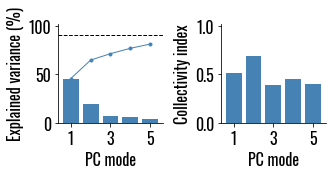

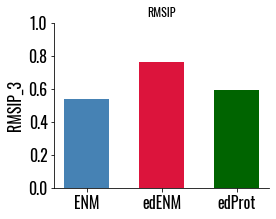

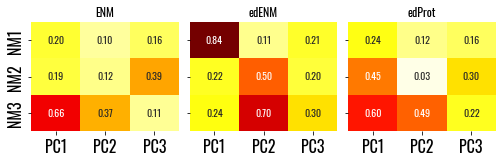

In [6]:
from ElasticNetworkModels import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from MDAnalysis.analysis.pca import PCA
import MDAnalysis as mda
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

from matplotlib import rcParams, font_manager

font_path = "./Oswald_font/25844591784.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()

rcParams['font.family'] = font_name
rcParams['lines.linewidth'] = 1.0
rcParams['axes.labelsize'] = 16
rcParams['savefig.dpi'] = 300
rcParams['legend.fancybox'] = False
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 16
rcParams['ytick.labelsize'] = 16
rcParams['patch.linewidth'] = 2.0
rcParams['legend.frameon'] = False

# Optimal parameters set for protein-nucleic acid system
optimal_cutoff = 8
optimal_p_high = 2.2
optimal_C_high = 25
optimal_C_low = 30

pdbid = "1FJE" #Insert the PDB id of the protein-nucleic acid NMR you want to analyze

# Running PCA of the NMR ensemble
ensemble = mda.Universe(f"Complexes_NMR_structures_optimization/{pdbid}.pdb")
pca_res = PCA(ensemble, select="name CA P", align=True).run()
ref_eigvecs = pca_res.p_components 
print("Results PCA of the NMR ensemble")
collectivities = calcCollectivity(ref_eigvecs)
print(f"Collectivity for PC modes: {'-'.join([f'{c:.2f}' for c in collectivities[:5]])}")
expl_variance = pca_res.cumulated_variance - np.concatenate([[0],pca_res.cumulated_variance[:-1]])
print(f"Explained variance for PC modes: {'-'.join([f'{c:.2f}' for c in expl_variance[:5]])}")
N = np.where(pca_res.cumulated_variance > 0.9)[0][0]+1
print(f"Number of PC modes explaining 90% of variance: {N}")

fig, ax = plt.subplots(1,2,figsize=(12/2.54,6/2.54),sharex=True)
ax[0].bar(np.arange(1,6),expl_variance[:5]*100,color='steelblue')
ax[0].plot(np.arange(1,6),pca_res.cumulated_variance[:5]*100,color='steelblue',marker='o',markersize=3)
ax[0].axhline(90,linestyle='--',color='black')
ax[0].set_xlabel("PC mode")
ax[0].set_xticks(np.arange(1,6,step=2))
ax[0].set_ylabel("Explained variance (%)")
ax[0].set_ylim(0,102)
ax[1].bar(np.arange(1,6),collectivities[:5],color='steelblue')
ax[1].set_xlabel("PC mode")
ax[1].set_xticks(np.arange(1,6,step=2))
ax[1].set_ylabel("Collectivity index")
ax[1].set_ylim(0,1.02)
sns.despine()
fig.tight_layout()
fig.savefig(f"Images/NMR_PCA_{pdbid}.png",dpi=600,facecolor='w')

# Find the lowest RMSD frame to mean structure
sel = ensemble.select_atoms("name CA P")
ref_coordinates = np.stack([a.position for a in sel], axis=0).mean(axis=0)
rmsds = []
for _ in ensemble.trajectory:
    rmsds.append(np.sqrt(np.mean((sel.positions - ref_coordinates)**2)))
ensemble.trajectory[np.argmin(rmsds)]

# Write temp file
tmpfile = f"Complexes_NMR_structures_optimization/{pdbid}_tmp.pdb"
mod_id = pdbid + "_tmp"
ensemble.atoms.write(tmpfile)

print(f"Running edENM, ENM, and edProt for NMR of {pdbid}")

# Running edENM with optimal parameters
ed_model = edENM(cutoff_inter=optimal_cutoff,C_high=optimal_C_high,C_low=optimal_C_low,p_high=optimal_p_high)
ed_model.extract_ca_coordinates_and_masses(tmpfile)
ed_model.construct_hessian(mod_id, build_gamma=True)
ed_model.solve_eigenproblem(mod_id)
ed_model.compute_vectors_for_NMA(mod_id, num_modes=5)
    
ed_eigens = []
for mode, mode_eigenvecs in ed_model.eigenvecs_reshaped[mod_id].items():
    # get only indices for C-alpha atoms and P atoms
    mode_eigenvecs = mode_eigenvecs[(np.array(ed_model.coord_dict[mod_id][3]) == "P")|(np.array(ed_model.coord_dict[mod_id][3]) == "CA")].ravel()
    ed_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
ed_eigens = np.column_stack(ed_eigens)

# Running classical ENM (ANM for protein + Bussi for nucleic acid)
classic = classicENM()
classic.extract_ca_coordinates_and_masses(tmpfile)
classic.construct_hessian(mod_id, edProt=False)
classic.solve_eigenproblem(mod_id)
classic.compute_vectors_for_NMA(mod_id, num_modes=5)
    
classic_eigens = []
for mode, mode_eigenvecs in classic.eigenvecs_reshaped[mod_id].items():
    # get only indices for C-alpha atoms and P atoms
    mode_eigenvecs = mode_eigenvecs[(np.array(classic.coord_dict[mod_id][3]) == "P")|(np.array(classic.coord_dict[mod_id][3]) == "CA")].ravel()
    classic_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
classic_eigens = np.column_stack(classic_eigens)

# Running edProt(edENM for protein + Bussi for nucleic acid)
edProt = classicENM()
edProt.extract_ca_coordinates_and_masses(tmpfile)
edProt.construct_hessian(mod_id, edProt=True)
edProt.solve_eigenproblem(mod_id)
edProt.compute_vectors_for_NMA(mod_id, num_modes=5)

edProt_eigens = []
for mode, mode_eigenvecs in edProt.eigenvecs_reshaped[mod_id].items():
    # get only indices for C-alpha atoms and P atoms
    mode_eigenvecs = mode_eigenvecs[(np.array(edProt.coord_dict[mod_id][3]) == "P")|(np.array(edProt.coord_dict[mod_id][3]) == "CA")].ravel()
    edProt_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
edProt_eigens = np.column_stack(edProt_eigens)
    
os.remove(tmpfile)

# Computing overlaps
rmsips = {"ENM": None,"edENM": None, "edProt": None}
overlaps = {"ENM": None,"edENM": None,"edProt": None}

for label, eigens in [("ENM", classic_eigens),("edENM", ed_eigens),("edProt", edProt_eigens)]:
    o, cum_overlap = calcOverlap(enm_vecs=eigens,pca_vecs=ref_eigvecs,n_enm=3, n_pca=3)
    rmsip = calcRMSIP(eigens, ref_eigvecs, 3)

    overlaps[label] = o
    rmsips[label] = rmsip
    
    max_val = np.max(o)
    i, j = np.unravel_index(np.argmax(o), o.shape)
    nm_index = i + 1
    pc_index = j + 1

    print(f"\t{label}")
    print(f"\t\tRMSIP = {rmsip:.3f}")
    print(f"\t\tCSO = {cum_overlap}")
    print(f"\t\tMax overlap = {max_val:.3f} (NM {nm_index}, PC {pc_index})")
    
# Printing of NM results
models = ["ENM", "edENM", "edProt"]
colors = {"ENM": "steelblue","edENM": "crimson","edProt": "darkgreen"}

plt.figure(figsize=(10/2.54, 8/2.54))
for i, m in enumerate(models):
    plt.bar(i, rmsips[m], color=colors[m], width=0.6)
plt.xticks(range(3), models)
plt.ylabel("RMSIP_3")
plt.ylim(0, 1)
plt.title("RMSIP")
sns.despine()
plt.tight_layout()
plt.savefig(f"Images/RMSIP_comparison_{pdbid}.png", dpi=600, facecolor='w')

fig, ax = plt.subplots(1, 3, figsize=(18/2.54, 6/2.54), sharex=True, sharey=True)
for j, m in enumerate(models):
    sns.heatmap(
        overlaps[m][:3, :3],            # Only 3×3 block
        annot=True, fmt=".2f",
        cmap='hot_r', cbar=False,
        vmin=0, vmax=1,
        ax=ax[j],
        xticklabels=["PC1", "PC2", "PC3"],
        yticklabels=["NM1", "NM2", "NM3"],
    )
    ax[j].set_title(m)

fig.tight_layout()
fig.savefig(f"Images/overlap_matrix_{pdbid}.png", dpi=600, facecolor='w')

# Print PC1 and NM movies for edENM, ENM, edProt (NM with the highest overlap with PC1)
print("\nGenerating movies...")
if not os.path.isdir("movies"):
    os.mkdir("movies")
traj_uni = mda.Universe(f"Complexes_NMR_structures_optimization/{pdbid}.pdb")
pc1_vec = ref_eigvecs[:, [0]]   # keeps 2-D shape (N,1)  # PC1 eigenvector - change idex if you want to analyze a different PC
makeTraj(pc1_vec,f"Complexes_NMR_structures_optimization/{pdbid}.pdb",f"movies/{pdbid}_PC1.pdb",steps=5,ampl=30,modes=[0],selection="name CA P")

for label, eigens in [("ENM", classic_eigens),("edENM", ed_eigens),("edProt", edProt_eigens)]:
    # Find NM with maximum overlap vs PC1 (PC index = 0) - change index if you want to see movies with highest overlaps with other PCs
    best_nm = np.argmax(overlaps[label][:, 0])  # 0-based NM index
    print(f"\tMovie: {label} best NM for PC1 → NM{best_nm+1}")
    enm_vec = eigens[:, [best_nm]]
    makeTraj(enm_vec,f"Complexes_NMR_structures_optimization/{pdbid}.pdb",f"movies/{pdbid}_{label}_NM{best_nm+1}.pdb",steps=5,ampl=30,modes=[0],selection="name CA P")
print("\nMovies generated!")

# Evaluation of edENM performance on ensembles of protein-nucleic acid systems

Analyzing ensemble 1
Number of meaningful PCs: 1
Collectivties of ensemble PCs: 0.72
Computing NMs for 4WLS_ABC...
	ENM
		RMSIP = 0.367
		Max overlap = 0.367 (NM 1, PC 1)
		NM1 collectivity = 0.392
	edProt
		RMSIP = 0.143
		Max overlap = 0.491 (NM 2, PC 1)
		NM1 collectivity = 0.282
	edENM
		RMSIP = 0.203
		Max overlap = 0.702 (NM 3, PC 1)
		NM1 collectivity = 0.176
Computing NMs for 4WLW_ABC...
	ENM
		RMSIP = 0.176
		Max overlap = 0.365 (NM 2, PC 1)
		NM1 collectivity = 0.388
	edProt
		RMSIP = 0.009
		Max overlap = 0.290 (NM 2, PC 1)
		NM1 collectivity = 0.227
	edENM
		RMSIP = 0.178
		Max overlap = 0.566 (NM 3, PC 1)
		NM1 collectivity = 0.165

=== Average overlap values for Ensemble 1 ===
BEST_OVERLAP:
   ENM    = 0.366
   edProt = 0.390
   edENM  = 0.634
RMSIP:
   ENM    = 0.271
   edProt = 0.076
   edENM  = 0.191

=== Maximum overlap values for Ensemble 1 ===
BEST_OVERLAP:
   ENM    = 0.367
   edProt = 0.491
   edENM  = 0.702
RMSIP:
   ENM    = 0.367
   edProt = 0.143
   edENM  = 0

	ENM
		RMSIP = 0.578
		Max overlap = 0.679 (NM 1, PC 1)
		NM1 collectivity = 0.114
	edProt
		RMSIP = 0.631
		Max overlap = 0.708 (NM 1, PC 1)
		NM1 collectivity = 0.134
	edENM
		RMSIP = 0.496
		Max overlap = 0.430 (NM 1, PC 1)
		NM1 collectivity = 0.546
Computing NMs for 05DW_AB...
	ENM
		RMSIP = 0.547
		Max overlap = 0.635 (NM 1, PC 2)
		NM1 collectivity = 0.343
	edProt
		RMSIP = 0.565
		Max overlap = 0.617 (NM 1, PC 2)
		NM1 collectivity = 0.490
	edENM
		RMSIP = 0.410
		Max overlap = 0.413 (NM 3, PC 2)
		NM1 collectivity = 0.565
Computing NMs for 05DY_AB...
	ENM
		RMSIP = 0.618
		Max overlap = 0.649 (NM 1, PC 1)
		NM1 collectivity = 0.120
	edProt
		RMSIP = 0.674
		Max overlap = 0.694 (NM 1, PC 1)
		NM1 collectivity = 0.139
	edENM
		RMSIP = 0.622
		Max overlap = 0.773 (NM 1, PC 1)
		NM1 collectivity = 0.401
Computing NMs for 06DW_AB...
	ENM
		RMSIP = 0.496
		Max overlap = 0.670 (NM 1, PC 2)
		NM1 collectivity = 0.377
	edProt
		RMSIP = 0.528
		Max overlap = 0.694 (NM 1, PC 2)
		NM1 col

	ENM
		RMSIP = 0.593
		Max overlap = 0.586 (NM 1, PC 2)
		NM1 collectivity = 0.332
	edProt
		RMSIP = 0.593
		Max overlap = 0.637 (NM 1, PC 2)
		NM1 collectivity = 0.484
	edENM
		RMSIP = 0.454
		Max overlap = 0.406 (NM 1, PC 2)
		NM1 collectivity = 0.580
Computing NMs for 19DY_AB...
	ENM
		RMSIP = 0.612
		Max overlap = 0.620 (NM 1, PC 1)
		NM1 collectivity = 0.093
	edProt
		RMSIP = 0.655
		Max overlap = 0.668 (NM 1, PC 1)
		NM1 collectivity = 0.107
	edENM
		RMSIP = 0.623
		Max overlap = 0.789 (NM 1, PC 1)
		NM1 collectivity = 0.430
Computing NMs for 20DW_AB...
	ENM
		RMSIP = 0.587
		Max overlap = 0.468 (NM 3, PC 3)
		NM1 collectivity = 0.174
	edProt
		RMSIP = 0.581
		Max overlap = 0.582 (NM 1, PC 2)
		NM1 collectivity = 0.376
	edENM
		RMSIP = 0.422
		Max overlap = 0.573 (NM 3, PC 2)
		NM1 collectivity = 0.244
Computing NMs for 20DY_AB...
	ENM
		RMSIP = 0.588
		Max overlap = 0.569 (NM 1, PC 1)
		NM1 collectivity = 0.101
	edProt
		RMSIP = 0.659
		Max overlap = 0.639 (NM 2, PC 3)
		NM1 col

	ENM
		RMSIP = 0.562
		Max overlap = 0.584 (NM 2, PC 3)
		NM1 collectivity = 0.579
	edProt
		RMSIP = 0.562
		Max overlap = 0.585 (NM 2, PC 3)
		NM1 collectivity = 0.579
	edENM
		RMSIP = 0.574
		Max overlap = 0.597 (NM 2, PC 3)
		NM1 collectivity = 0.582

=== Average overlap values for Ensemble 12 ===
BEST_OVERLAP:
   ENM    = 0.502
   edProt = 0.515
   edENM  = 0.565
RMSIP:
   ENM    = 0.462
   edProt = 0.470
   edENM  = 0.476

=== Maximum overlap values for Ensemble 12 ===
BEST_OVERLAP:
   ENM    = 0.584
   edProt = 0.585
   edENM  = 0.621
RMSIP:
   ENM    = 0.562
   edProt = 0.562
   edENM  = 0.576


Analyzing ensemble 13
Number of meaningful PCs: 4
Collectivties of ensemble PCs: 0.80 - 0.51 - 0.43
Computing NMs for 5EJK_ABCDEFGHIJKL...
	ENM
		RMSIP = 0.434
		Max overlap = 0.421 (NM 2, PC 3)
		NM1 collectivity = 0.021
	edProt
		RMSIP = 0.482
		Max overlap = 0.468 (NM 1, PC 2)
		NM1 collectivity = 0.632
	edENM
		RMSIP = 0.457
		Max overlap = 0.423 (NM 1, PC 3)
		NM1 collectivity = 0.6

	ENM
		RMSIP = 0.196
		Max overlap = 0.224 (NM 2, PC 3)
		NM1 collectivity = 0.032
	edProt
		RMSIP = 0.481
		Max overlap = 0.636 (NM 3, PC 3)
		NM1 collectivity = 0.033
	edENM
		RMSIP = 0.595
		Max overlap = 0.597 (NM 1, PC 3)
		NM1 collectivity = 0.361
Computing NMs for 6JE9_AB...
	ENM
		RMSIP = 0.107
		Max overlap = 0.129 (NM 2, PC 1)
		NM1 collectivity = 0.032
	edProt
		RMSIP = 0.459
		Max overlap = 0.635 (NM 3, PC 3)
		NM1 collectivity = 0.035
	edENM
		RMSIP = 0.594
		Max overlap = 0.589 (NM 1, PC 3)
		NM1 collectivity = 0.365
Computing NMs for 6JE9_CD...
	ENM
		RMSIP = 0.191
		Max overlap = 0.204 (NM 1, PC 3)
		NM1 collectivity = 0.043
	edProt
		RMSIP = 0.333
		Max overlap = 0.296 (NM 3, PC 1)
		NM1 collectivity = 0.051
	edENM
		RMSIP = 0.601
		Max overlap = 0.627 (NM 1, PC 3)
		NM1 collectivity = 0.400
Computing NMs for 6KC7_AB...
	ENM
		RMSIP = 0.498
		Max overlap = 0.720 (NM 1, PC 2)
		NM1 collectivity = 0.224
	edProt
		RMSIP = 0.525
		Max overlap = 0.678 (NM 3, PC 2)
		NM1 col

	ENM
		RMSIP = 0.405
		Max overlap = 0.513 (NM 2, PC 1)
		NM1 collectivity = 0.003
	edProt
		RMSIP = 0.472
		Max overlap = 0.475 (NM 2, PC 2)
		NM1 collectivity = 0.514
	edENM
		RMSIP = 0.565
		Max overlap = 0.534 (NM 3, PC 2)
		NM1 collectivity = 0.528
Computing NMs for 3V72_APT...
	ENM
		RMSIP = 0.553
		Max overlap = 0.525 (NM 2, PC 1)
		NM1 collectivity = 0.709
	edProt
		RMSIP = 0.545
		Max overlap = 0.566 (NM 2, PC 1)
		NM1 collectivity = 0.709
	edENM
		RMSIP = 0.637
		Max overlap = 0.575 (NM 1, PC 1)
		NM1 collectivity = 0.489
Computing NMs for 3V7J_APT...
	ENM
		RMSIP = 0.548
		Max overlap = 0.507 (NM 2, PC 1)
		NM1 collectivity = 0.003
	edProt
		RMSIP = 0.544
		Max overlap = 0.546 (NM 1, PC 1)
		NM1 collectivity = 0.476
	edENM
		RMSIP = 0.641
		Max overlap = 0.565 (NM 1, PC 1)
		NM1 collectivity = 0.494
Computing NMs for 3V7K_APT...
	ENM
		RMSIP = 0.387
		Max overlap = 0.484 (NM 3, PC 1)
		NM1 collectivity = 0.006
	edProt
		RMSIP = 0.403
		Max overlap = 0.535 (NM 3, PC 1)
		NM1 

	ENM
		RMSIP = 0.713
		Max overlap = 0.554 (NM 1, PC 3)
		NM1 collectivity = 0.556
	edProt
		RMSIP = 0.687
		Max overlap = 0.705 (NM 1, PC 1)
		NM1 collectivity = 0.520
	edENM
		RMSIP = 0.746
		Max overlap = 0.740 (NM 2, PC 1)
		NM1 collectivity = 0.660
Computing NMs for 09EJ_ABCD...
	ENM
		RMSIP = 0.729
		Max overlap = 0.546 (NM 1, PC 1)
		NM1 collectivity = 0.140
	edProt
		RMSIP = 0.696
		Max overlap = 0.756 (NM 1, PC 1)
		NM1 collectivity = 0.233
	edENM
		RMSIP = 0.786
		Max overlap = 0.615 (NM 2, PC 3)
		NM1 collectivity = 0.629
Computing NMs for 09EK_ABCD...
	ENM
		RMSIP = 0.716
		Max overlap = 0.691 (NM 1, PC 1)
		NM1 collectivity = 0.565
	edProt
		RMSIP = 0.697
		Max overlap = 0.713 (NM 1, PC 1)
		NM1 collectivity = 0.597
	edENM
		RMSIP = 0.750
		Max overlap = 0.690 (NM 2, PC 1)
		NM1 collectivity = 0.641
Computing NMs for 10EI_ABCD...
	ENM
		RMSIP = 0.673
		Max overlap = 0.598 (NM 2, PC 3)
		NM1 collectivity = 0.089
	edProt
		RMSIP = 0.667
		Max overlap = 0.703 (NM 1, PC 1)
		N

	ENM
		RMSIP = 0.460
		Max overlap = 0.520 (NM 3, PC 3)
		NM1 collectivity = 0.412
	edProt
		RMSIP = 0.410
		Max overlap = 0.439 (NM 2, PC 2)
		NM1 collectivity = 0.418
	edENM
		RMSIP = 0.363
		Max overlap = 0.371 (NM 2, PC 2)
		NM1 collectivity = 0.417
Computing NMs for 4G0W_ABCDEF...
	ENM
		RMSIP = 0.467
		Max overlap = 0.527 (NM 3, PC 3)
		NM1 collectivity = 0.415
	edProt
		RMSIP = 0.413
		Max overlap = 0.446 (NM 2, PC 2)
		NM1 collectivity = 0.420
	edENM
		RMSIP = 0.341
		Max overlap = 0.376 (NM 2, PC 2)
		NM1 collectivity = 0.418
Computing NMs for 4J3N_ABCDEF...
	ENM
		RMSIP = 0.468
		Max overlap = 0.510 (NM 3, PC 3)
		NM1 collectivity = 0.413
	edProt
		RMSIP = 0.410
		Max overlap = 0.467 (NM 2, PC 2)
		NM1 collectivity = 0.420
	edENM
		RMSIP = 0.411
		Max overlap = 0.450 (NM 2, PC 2)
		NM1 collectivity = 0.419
Computing NMs for 5GWI_ABCDEF...
	ENM
		RMSIP = 0.463
		Max overlap = 0.511 (NM 3, PC 3)
		NM1 collectivity = 0.411
	edProt
		RMSIP = 0.413
		Max overlap = 0.465 (NM 2, PC 

	ENM
		RMSIP = 0.266
		Max overlap = 0.274 (NM 3, PC 2)
		NM1 collectivity = 0.102
	edProt
		RMSIP = 0.386
		Max overlap = 0.454 (NM 1, PC 1)
		NM1 collectivity = 0.283
	edENM
		RMSIP = 0.465
		Max overlap = 0.472 (NM 2, PC 2)
		NM1 collectivity = 0.139
Computing NMs for 4ZT0_AB...
	ENM
		RMSIP = 0.449
		Max overlap = 0.452 (NM 1, PC 1)
		NM1 collectivity = 0.068
	edProt
		RMSIP = 0.369
		Max overlap = 0.455 (NM 1, PC 1)
		NM1 collectivity = 0.481
	edENM
		RMSIP = 0.389
		Max overlap = 0.450 (NM 1, PC 1)
		NM1 collectivity = 0.456
Computing NMs for 4ZT9_AB...
	ENM
		RMSIP = 0.488
		Max overlap = 0.590 (NM 1, PC 1)
		NM1 collectivity = 0.084
	edProt
		RMSIP = 0.390
		Max overlap = 0.523 (NM 1, PC 1)
		NM1 collectivity = 0.526
	edENM
		RMSIP = 0.400
		Max overlap = 0.528 (NM 1, PC 1)
		NM1 collectivity = 0.492
Computing NMs for 5B2R_AB...
	ENM
		RMSIP = 0.249
		Max overlap = 0.215 (NM 2, PC 3)
		NM1 collectivity = 0.092
	edProt
		RMSIP = 0.460
		Max overlap = 0.456 (NM 1, PC 1)
		NM1 col

	ENM
		RMSIP = 0.309
		Max overlap = 0.355 (NM 3, PC 2)
		NM1 collectivity = 0.109
	edProt
		RMSIP = 0.382
		Max overlap = 0.446 (NM 1, PC 1)
		NM1 collectivity = 0.283
	edENM
		RMSIP = 0.435
		Max overlap = 0.458 (NM 2, PC 2)
		NM1 collectivity = 0.138
Computing NMs for 7QQS_AB...
	ENM
		RMSIP = 0.303
		Max overlap = 0.345 (NM 3, PC 2)
		NM1 collectivity = 0.108
	edProt
		RMSIP = 0.383
		Max overlap = 0.444 (NM 1, PC 1)
		NM1 collectivity = 0.277
	edENM
		RMSIP = 0.448
		Max overlap = 0.461 (NM 2, PC 2)
		NM1 collectivity = 0.140
Computing NMs for 7QQT_AB...
	ENM
		RMSIP = 0.308
		Max overlap = 0.338 (NM 3, PC 2)
		NM1 collectivity = 0.108
	edProt
		RMSIP = 0.383
		Max overlap = 0.439 (NM 1, PC 1)
		NM1 collectivity = 0.225
	edENM
		RMSIP = 0.460
		Max overlap = 0.460 (NM 2, PC 2)
		NM1 collectivity = 0.138
Computing NMs for 7QQU_AB...
	ENM
		RMSIP = 0.303
		Max overlap = 0.343 (NM 3, PC 2)
		NM1 collectivity = 0.107
	edProt
		RMSIP = 0.381
		Max overlap = 0.440 (NM 1, PC 1)
		NM1 col

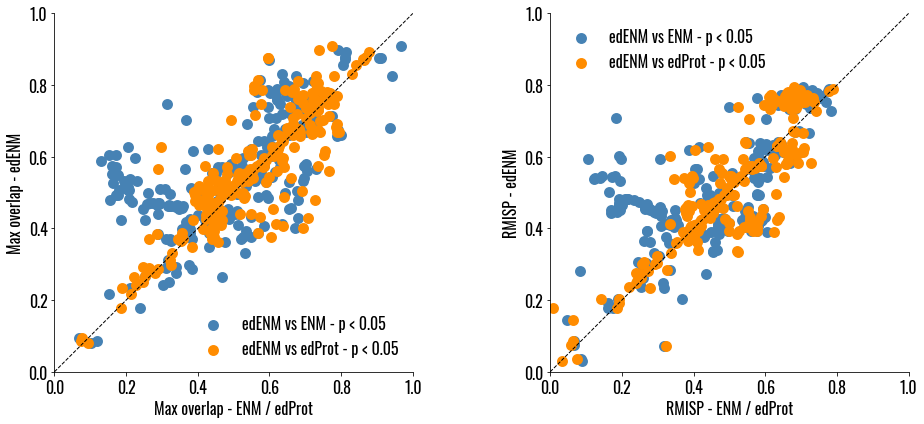

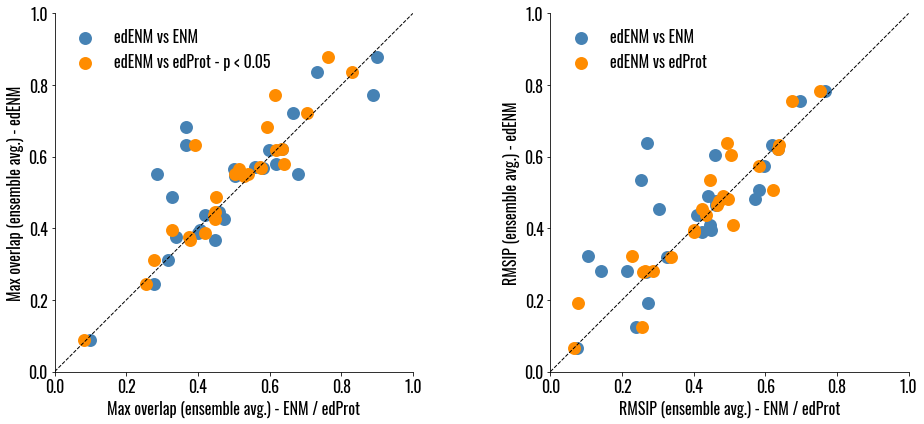

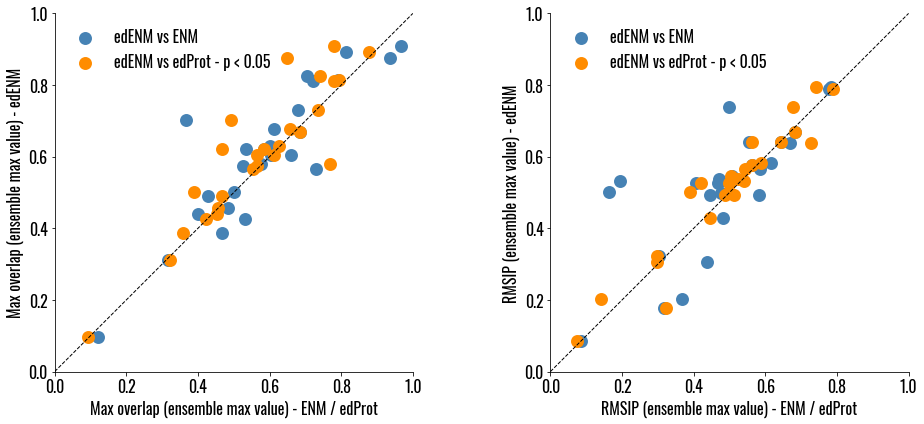

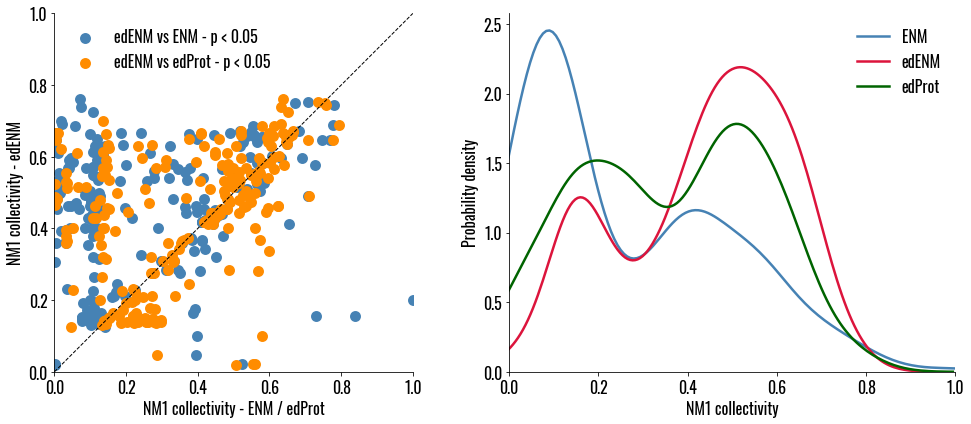

In [2]:
from ElasticNetworkModels import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from MDAnalysis.analysis.pca import PCA
import MDAnalysis as mda
from MDAnalysis.analysis import align
import sys
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import mannwhitneyu, wilcoxon

from matplotlib import rcParams, font_manager

font_path = "./Oswald_font/25844591784.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()

rcParams['font.family'] = font_name
rcParams['lines.linewidth'] = 1.0
rcParams['axes.labelsize'] = 16
rcParams['savefig.dpi'] = 300
rcParams['legend.fancybox'] = False
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 16
rcParams['ytick.labelsize'] = 16
rcParams['patch.linewidth'] = 2.0
rcParams['legend.frameon'] = False


results = defaultdict(list)
ensemble_average_results = defaultdict(list)
ensemble_max_results = defaultdict(list)
nm1_collectivities = defaultdict(list)

# Optimal parameters set for protein-nucleic acid system
optimal_cutoff = 8
optimal_p_high = 2.2
optimal_C_high = 25
optimal_C_low = 30

for N in range(1,27):
    print(f"Analyzing ensemble {N}")
    
    ensemble_metrics = {
        "ENM": {"BEST_OVERLAP": [], "RMSIP": []},
        "edProt": {"BEST_OVERLAP": [], "RMSIP": []},
         "edENM": {"BEST_OVERLAP": [], "RMSIP": []},
    }
    
    pdbs, chains = [], []
    with open(f"Complexes_ensembles_testing/ensemble_{N}/ensemble.txt",'r') as fi:
        line = fi.readline()
        while line:
            pdbs.append(line.strip().split()[0])
            chains.append(line.strip().split()[1])
            line = fi.readline()
    
    # Read the PC eigenvectors
    n_meaningful_PCs = len(pdbs) - 1
    pca_eigens = np.loadtxt(f"Complexes_ensembles_testing/ensemble_{N}/PCs.txt")[:,:n_meaningful_PCs]
    collectivities = calcCollectivity(pca_eigens)
    print(f"Number of meaningful PCs: {n_meaningful_PCs}")
    print(f"Collectivties of ensemble PCs: {' - '.join([f'{c:.2f}' for c in collectivities[:3]])}")

    for pdb, chain in zip(pdbs,chains):
        print(f"Computing NMs for {pdb}_{chain}...")
        pdb_file = f"Complexes_ensembles_testing/ensemble_{N}/{pdb}_{chain}_CA_P_C1_C2_ali_labeled.pdb"
        pdb_code = f"{pdb}_{chain}_CA_P_C1_C2_ali_labeled"    

        model = edENM(cutoff_inter=optimal_cutoff,C_high=optimal_C_high,C_low=optimal_C_low,p_high=optimal_p_high)
        model.extract_ca_coordinates_and_masses(pdb_file)
        model.construct_hessian(pdb_code, build_gamma=False)
        model.solve_eigenproblem(pdb_code)
        model.compute_vectors_for_NMA(pdb_code,num_modes=3)
        ed_eigens = []
        for mode, mode_eigenvecs in model.eigenvecs_reshaped[pdb_code].items():
            mode_eigenvecs = mode_eigenvecs[(np.array(model.coord_dict[pdb_code][3]) == "P")|(np.array(model.coord_dict[pdb_code][3]) == "CA")].ravel()
            ed_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
        ed_eigens = np.column_stack(ed_eigens)
        
        ed_eigens_full = []
        for mode, mode_eigenvecs in model.eigenvecs_reshaped[pdb_code].items():
            #mode_eigenvecs = mode_eigenvecs[(np.array(model.coord_dict[pdb_code][3]) == "P")|(np.array(model.coord_dict[pdb_code][3]) == "C2")|(np.array(model.coord_dict[pdb_code][3]) == "C1'")].ravel()
            mode_eigenvecs = mode_eigenvecs[(np.array(model.coord_dict[pdb_code][3]) == "P")|(np.array(model.coord_dict[pdb_code][3]) == "C2")|(np.array(model.coord_dict[pdb_code][3]) == "C1'")|(np.array(model.coord_dict[pdb_code][3]) == "CA")].ravel()
            ed_eigens_full.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
        ed_eigens_full = np.column_stack(ed_eigens_full)
        edENM_collectivity = calcCollectivity(ed_eigens_full)
        nm1_collectivities["edENM"].append(edENM_collectivity[0])
        
        classic = classicENM()
        classic.extract_ca_coordinates_and_masses(pdb_file)
        classic.construct_hessian(pdb_code, edProt=False)
        classic.solve_eigenproblem(pdb_code)
        classic.compute_vectors_for_NMA(pdb_code,num_modes=3)
        classic_eigens = []
        for mode, mode_eigenvecs in classic.eigenvecs_reshaped[pdb_code].items():
            mode_eigenvecs = mode_eigenvecs[(np.array(classic.coord_dict[pdb_code][3]) == "P")|(np.array(classic.coord_dict[pdb_code][3]) == "CA")].ravel()
            classic_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
        classic_eigens = np.column_stack(classic_eigens)
        
        classic_eigens_full = []
        for mode, mode_eigenvecs in classic.eigenvecs_reshaped[pdb_code].items():
            mode_eigenvecs = mode_eigenvecs[(np.array(classic.coord_dict[pdb_code][3]) == "P")|(np.array(classic.coord_dict[pdb_code][3]) == "C2")|(np.array(classic.coord_dict[pdb_code][3]) == "C1'")|(np.array(classic.coord_dict[pdb_code][3]) == "CA")].ravel()
            classic_eigens_full.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
        classic_eigens_full = np.column_stack(classic_eigens_full)
        ENM_collectivity = calcCollectivity(classic_eigens_full)
        nm1_collectivities["ENM"].append(ENM_collectivity[0])
        
        edProt = classicENM()
        edProt.extract_ca_coordinates_and_masses(pdb_file)
        edProt.construct_hessian(pdb_code, edProt=True)
        edProt.solve_eigenproblem(pdb_code)
        edProt.compute_vectors_for_NMA(pdb_code,num_modes=3)
        edProt_eigens = []
        for mode, mode_eigenvecs in edProt.eigenvecs_reshaped[pdb_code].items():
            mode_eigenvecs = mode_eigenvecs[(np.array(edProt.coord_dict[pdb_code][3]) == "P")|(np.array(edProt.coord_dict[pdb_code][3]) == "CA")].ravel()
            edProt_eigens.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
        edProt_eigens = np.column_stack(edProt_eigens)
    
        edProt_eigens_full = []
        for mode, mode_eigenvecs in edProt.eigenvecs_reshaped[pdb_code].items():
            mode_eigenvecs = mode_eigenvecs[(np.array(edProt.coord_dict[pdb_code][3]) == "P")|(np.array(edProt.coord_dict[pdb_code][3]) == "C2")|(np.array(edProt.coord_dict[pdb_code][3]) == "C1'")|(np.array(edProt.coord_dict[pdb_code][3]) == "CA")].ravel()
            edProt_eigens_full.append(mode_eigenvecs / np.linalg.norm(mode_eigenvecs, axis=0))
        edProt_eigens_full = np.column_stack(edProt_eigens_full)
        edProt_collectivity = calcCollectivity(edProt_eigens_full)
        nm1_collectivities["edProt"].append(edProt_collectivity[0])
        
        # Computing overlaps
        for label, eigens in [("ENM", classic_eigens),("edProt", edProt_eigens),("edENM", ed_eigens)]:
            if n_meaningful_PCs <= 3:
                o, _ = calcOverlap(enm_vecs=eigens,pca_vecs=pca_eigens,n_enm=3, n_pca=n_meaningful_PCs)
                rmsip = calcRMSIP(eigens, pca_eigens, n_meaningful_PCs)
            else:
                o, _ = calcOverlap(enm_vecs=eigens,pca_vecs=pca_eigens,n_enm=3, n_pca=3)
                rmsip = calcRMSIP(eigens, pca_eigens, 3)

            max_val = np.max(o)
            if o.ndim == 1:
                i = np.argmax(o)
                j = 0
            else:
                i, j = np.unravel_index(np.argmax(o), o.shape)
            
            nm_index = i + 1
            pc_index = j + 1

            print(f"\t{label}")
            print(f"\t\tRMSIP = {rmsip:.3f}")
            print(f"\t\tMax overlap = {max_val:.3f} (NM {nm_index}, PC {pc_index})")
            
            if label == "ENM":
                print(f"\t\tNM1 collectivity = {ENM_collectivity[0]:.3f}")
            elif label == "edProt":
                print(f"\t\tNM1 collectivity = {edProt_collectivity[0]:.3f}")
            else:
                print(f"\t\tNM1 collectivity = {edENM_collectivity[0]:.3f}")

            results[f"{label}_RMSIP"].append(rmsip)
            results[f"{label}_BEST_OVERLAP"].append(max_val)
            
            ensemble_metrics[label]["RMSIP"].append(rmsip)
            ensemble_metrics[label]["BEST_OVERLAP"].append(max_val)
    
    for label in ["ENM", "edProt", "edENM"]:
        for metric in ["BEST_OVERLAP", "RMSIP"]:
            arr = np.array(ensemble_metrics[label][metric])
            mean_val = np.mean(arr)
            ensemble_average_results[f"{label}_{metric}"].append(mean_val)
            max_val = np.max(arr)
            ensemble_max_results[f"{label}_{metric}"].append(max_val)
            
    print(f"\n=== Average overlap values for Ensemble {N} ===")
    for metric in ["BEST_OVERLAP", "RMSIP"]:
        enm_mean    = ensemble_average_results[f"ENM_{metric}"][-1]
        edprot_mean = ensemble_average_results[f"edProt_{metric}"][-1]
        edenm_mean  = ensemble_average_results[f"edENM_{metric}"][-1]

        print(f"{metric}:")
        print(f"   ENM    = {enm_mean:.3f}")
        print(f"   edProt = {edprot_mean:.3f}")
        print(f"   edENM  = {edenm_mean:.3f}")
    
    print(f"\n=== Maximum overlap values for Ensemble {N} ===")
    for metric in ["BEST_OVERLAP", "RMSIP"]:
        enm_max    = ensemble_max_results[f"ENM_{metric}"][-1]
        edprot_max = ensemble_max_results[f"edProt_{metric}"][-1]
        edenm_max  = ensemble_max_results[f"edENM_{metric}"][-1]

        print(f"{metric}:")
        print(f"   ENM    = {enm_max:.3f}")
        print(f"   edProt = {edprot_max:.3f}")
        print(f"   edENM  = {edenm_max:.3f}")
            
    print("\n")

    
# Extract statistics
labels = ["ENM", "edProt", "edENM"]
metrics = ["BEST_OVERLAP", "RMSIP"]

summary = []
for label in labels:
    for metric in metrics:
        data = np.array(results[f"{label}_{metric}"])
        mean_val = np.mean(data)
        std_val = np.std(data)
        summary.append({"Model": label, "Metric": metric, "Mean": mean_val, "Std": std_val})

summary_df = pd.DataFrame(summary)
print("\n=== Summary of Overlap Metrics per individual PDB ===")
print(summary_df)

print("\n=== P-value Statistical Tests (Wilcoxon) per individual PDB overlaps ===")
for metric in metrics:
    enm_vals = np.array(results[f"ENM_{metric}"])
    edprot_vals = np.array(results[f"edProt_{metric}"])
    edenm_vals = np.array(results[f"edENM_{metric}"])
    
    # edENM vs ENM
    _, p_one_sided = wilcoxon(edenm_vals, enm_vals, alternative='greater')
    print(f"{metric} - edENM>ENM: p = {p_one_sided:.6f}")
    _, p_one_sided = wilcoxon(edenm_vals, enm_vals, alternative='less')
    print(f"{metric} - edENM<ENM: p = {p_one_sided:.6f}")
        
    # edENM vs edProt
    _, p_one_sided = wilcoxon(edenm_vals, edprot_vals, alternative='greater')
    print(f"{metric} - edENM>edProt: p = {p_one_sided:.6f}")
    _, p_one_sided = wilcoxon(edenm_vals, edprot_vals, alternative='less')
    print(f"{metric} - edENM<edProt: p = {p_one_sided:.6f}")
    
    # edProt vs ENM
    _, p_one_sided = wilcoxon(edprot_vals, enm_vals, alternative='greater')
    print(f"{metric} - edProt>ENM: p = {p_one_sided:.6f}")
    _, p_one_sided = wilcoxon(edprot_vals, enm_vals, alternative='less')
    print(f"{metric} - edProt<ENM: p = {p_one_sided:.6f}")

ensemble_summary = []
for label in ["ENM", "edProt", "edENM"]:
    for metric in ["BEST_OVERLAP", "RMSIP"]:
        arr = np.array(ensemble_average_results[f"{label}_{metric}"])
        ensemble_summary.append({
            "Model": label,
            "Metric": metric,
            "Mean_over_ensembles": np.mean(arr),
            "Std_over_ensembles": np.std(arr)
        })
        
ensemble_summary_df = pd.DataFrame(ensemble_summary)
print("\n=== Summary of Overlap Metrics per ensemble (averages) ===")
print(ensemble_summary_df)

print("\n=== P-value Statistical Tests (Wilcoxon) per ensemble (averages) overlaps ===")
for metric in ["BEST_OVERLAP", "RMSIP"]:
    enm_vals = np.array(ensemble_average_results[f"ENM_{metric}"])
    edprot_vals = np.array(ensemble_average_results[f"edProt_{metric}"])
    edenm_vals = np.array(ensemble_average_results[f"edENM_{metric}"])
    
    print(f"\n--- {metric} ---")

    # edENM vs ENM
    _, p = wilcoxon(edenm_vals, enm_vals, alternative='greater')
    print(f"edENM > ENM: p = {p:.6f}")
    _, p = wilcoxon(edenm_vals, enm_vals, alternative='less')
    print(f"edENM < ENM: p = {p:.6f}")

    # edENM vs edProt
    _, p = wilcoxon(edenm_vals, edprot_vals, alternative='greater')
    print(f"edENM > edProt: p = {p:.6f}")
    _, p = wilcoxon(edenm_vals, edprot_vals, alternative='less')
    print(f"edENM < edProt: p = {p:.6f}")

    # edProt vs ENM
    _, p = wilcoxon(edprot_vals, enm_vals, alternative='greater')
    print(f"edProt > ENM: p = {p:.6f}")
    _, p = wilcoxon(edprot_vals, enm_vals, alternative='less')
    print(f"edProt < ENM: p = {p:.6f}")
    
    
    
ensemble_max_summary = []
for label in ["ENM", "edProt", "edENM"]:
    for metric in ["BEST_OVERLAP", "RMSIP"]:
        arr = np.array(ensemble_max_results[f"{label}_{metric}"])
        ensemble_max_summary.append({
            "Model": label,
            "Metric": metric,
            "Mean_over_ensembles": np.mean(arr),
            "Std_over_ensembles": np.std(arr)
        })

ensemble_max_summary_df = pd.DataFrame(ensemble_max_summary)
print("\n=== Summary of Overlap Metrics per ensemble (maximum values) ===")
print(ensemble_max_summary_df)

print("\n=== P-value Statistical Tests (Wilcoxon) per ensemble (max values) overlaps ===")
for metric in ["BEST_OVERLAP", "RMSIP"]:
    enm_vals = np.array(ensemble_max_results[f"ENM_{metric}"])
    edprot_vals = np.array(ensemble_max_results[f"edProt_{metric}"])
    edenm_vals = np.array(ensemble_max_results[f"edENM_{metric}"])
    
    print(f"\n--- {metric} ---")

    # edENM vs ENM
    _, p = wilcoxon(edenm_vals, enm_vals, alternative='greater')
    print(f"edENM > ENM: p = {p:.6f}")
    _, p = wilcoxon(edenm_vals, enm_vals, alternative='less')
    print(f"edENM < ENM: p = {p:.6f}")

    # edENM vs edProt
    _, p = wilcoxon(edenm_vals, edprot_vals, alternative='greater')
    print(f"edENM > edProt: p = {p:.6f}")
    _, p = wilcoxon(edenm_vals, edprot_vals, alternative='less')
    print(f"edENM < edProt: p = {p:.6f}")

    # edProt vs ENM
    _, p = wilcoxon(edprot_vals, enm_vals, alternative='greater')
    print(f"edProt > ENM: p = {p:.6f}")
    _, p = wilcoxon(edprot_vals, enm_vals, alternative='less')
    print(f"edProt < ENM: p = {p:.6f}")
    
    
nm1_coll_summary = []
for model in ["ENM", "edProt", "edENM"]:
    key = f"{model}"
    arr = np.array(nm1_collectivities[key])
    nm1_coll_summary.append({
        "Model": model,
        "Mean": np.mean(arr),
        "Std": np.std(arr)
    })
nm1_coll_summary_df = pd.DataFrame(nm1_coll_summary)
print("\n=== Summary of NM1 Collectivities Across All PDBs ===")
print(nm1_coll_summary_df)
                  
print("\n=== Wilcoxon Tests: NM1 Collectivities ===")
enm_coll = np.array(nm1_collectivities["ENM"])
edprot_coll = np.array(nm1_collectivities["edProt"])
edenm_coll = np.array(nm1_collectivities["edENM"])

# edENM > ENM
_, p = wilcoxon(edenm_coll, enm_coll, alternative="greater")
print(f"edENM > ENM: p = {p:.6f}")
_, p = wilcoxon(edenm_coll, enm_coll, alternative="less")
print(f"edENM < ENM: p = {p:.6f}")

# edENM > edProt
_, p = wilcoxon(edenm_coll, edprot_coll, alternative="greater")
print(f"edENM > edProt: p = {p:.6f}")
_, p = wilcoxon(edenm_coll, edprot_coll, alternative="less")
print(f"edENM < edProt: p = {p:.6f}")

# edProt > ENM
_, p = wilcoxon(edprot_coll, enm_coll, alternative="greater")
print(f"edProt > ENM: p = {p:.6f}")
_, p = wilcoxon(edprot_coll, enm_coll, alternative="less")
print(f"edProt < ENM: p = {p:.6f}")                  

# --- Scatter Plot: one point per PDB overlaps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, metric in enumerate(metrics):
    enm_vals = np.array(results[f"ENM_{metric}"])
    edprot_vals = np.array(results[f"edProt_{metric}"])
    edenm_vals = np.array(results[f"edENM_{metric}"])
    
    _, p_one_sided_vs_ENM = wilcoxon(edenm_vals, enm_vals, alternative='greater')
    _, p_one_sided_vs_edProt = wilcoxon(edenm_vals, edprot_vals, alternative='greater')
    
    ax = axes[i]
    
    if p_one_sided_vs_ENM < 0.05:
        label_ENM = "edENM vs ENM - p < 0.05"
    else:
        label_ENM = "edENM vs ENM"
    ax.scatter(enm_vals, edenm_vals, s=80, color='steelblue', label=label_ENM)
    
    if p_one_sided_vs_edProt < 0.05:
        label_edProt = "edENM vs edProt - p < 0.05"
    else:
        label_edProt = "edENM vs edProt"
    ax.scatter(edprot_vals, edenm_vals, s=80, color='darkorange', label=label_edProt)
    
    ax.plot([0,1],[0,1],'k--')
    if metric == "BEST_OVERLAP":
        title = "Max overlap"
    else:
        title = "RMISP"
    ax.set_xlabel(f"{title} - ENM / edProt")
    ax.set_ylabel(f"{title} - edENM")
    ax.set_aspect('equal')
    ax.legend()
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    sns.despine()
fig.tight_layout()
fig.savefig("Images/Protein_nucleic_acid_ensembles_edENM_ENM_edProt_comparison_all_PDBs_overlaps.png",dpi=600,facecolor='w')


# --- Scatter Plots: One point per ensemble (averages) overlaps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, metric in enumerate(metrics):
    enm_vals    = np.array(ensemble_average_results[f"ENM_{metric}"])
    edprot_vals = np.array(ensemble_average_results[f"edProt_{metric}"])
    edenm_vals  = np.array(ensemble_average_results[f"edENM_{metric}"])
    
    _, p_one_sided_vs_ENM    = wilcoxon(edenm_vals, enm_vals, alternative='greater')
    _, p_one_sided_vs_edProt = wilcoxon(edenm_vals, edprot_vals, alternative='greater')

    ax = axes[i]

    if p_one_sided_vs_ENM < 0.05:
        label_ENM = "edENM vs ENM - p < 0.05"
    else:
        label_ENM = "edENM vs ENM"
    ax.scatter(enm_vals, edenm_vals, s=120, color='steelblue', label=label_ENM)

    if p_one_sided_vs_edProt < 0.05:
        label_edProt = "edENM vs edProt - p < 0.05"
    else:
        label_edProt = "edENM vs edProt"
    ax.scatter(edprot_vals, edenm_vals, s=120, color='darkorange', label=label_edProt)

    ax.plot([0, 1], [0, 1], 'k--')

    # axis labels
    if metric == "BEST_OVERLAP":
        title = "Max overlap (ensemble avg.)"
    else:
        title = "RMSIP (ensemble avg.)"

    ax.set_xlabel(f"{title} - ENM / edProt")
    ax.set_ylabel(f"{title} - edENM")
    ax.set_aspect('equal')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    sns.despine()

fig.tight_layout()
fig.savefig("Images/Protein_nucleic_acid_ensembles_edENM_ENM_edProt_comparison_ensembles_averages_overlaps.png",dpi=600, facecolor='w')

# --- Scatter Plots: One point per ensemble (max values) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, metric in enumerate(metrics):
    enm_vals    = np.array(ensemble_max_results[f"ENM_{metric}"])
    edprot_vals = np.array(ensemble_max_results[f"edProt_{metric}"])
    edenm_vals  = np.array(ensemble_max_results[f"edENM_{metric}"])
    
    _, p_one_sided_vs_ENM    = wilcoxon(edenm_vals, enm_vals, alternative='greater')
    _, p_one_sided_vs_edProt = wilcoxon(edenm_vals, edprot_vals, alternative='greater')

    ax = axes[i]

    if p_one_sided_vs_ENM < 0.05:
        label_ENM = "edENM vs ENM - p < 0.05"
    else:
        label_ENM = "edENM vs ENM"
    ax.scatter(enm_vals, edenm_vals, s=120, color='steelblue', label=label_ENM)

    if p_one_sided_vs_edProt < 0.05:
        label_edProt = "edENM vs edProt - p < 0.05"
    else:
        label_edProt = "edENM vs edProt"
    ax.scatter(edprot_vals, edenm_vals, s=120, color='darkorange', label=label_edProt)

    ax.plot([0, 1], [0, 1], 'k--')

    # axis labels
    if metric == "BEST_OVERLAP":
        title = "Max overlap (ensemble max value)"
    else:
        title = "RMSIP (ensemble max value)"

    ax.set_xlabel(f"{title} - ENM / edProt")
    ax.set_ylabel(f"{title} - edENM")
    ax.set_aspect('equal')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    sns.despine()

fig.tight_layout()
fig.savefig("Images/Protein_nucleic_acid_ensembles_edENM_ENM_edProt_comparison_ensembles_max_overlaps.png",dpi=600, facecolor='w')

# --- Scatter Plot: one point per PDB NM1 collectivities ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
enm_vals = np.array(nm1_collectivities["ENM"])
edprot_vals = np.array(nm1_collectivities["edProt"])
edenm_vals = np.array(nm1_collectivities["edENM"])
    
_, p_one_sided_vs_ENM = wilcoxon(edenm_vals, enm_vals, alternative='greater')
_, p_one_sided_vs_edProt = wilcoxon(edenm_vals, edprot_vals, alternative='greater')
    
ax = axes[0]

if p_one_sided_vs_ENM < 0.05:
    label_ENM = "edENM vs ENM - p < 0.05"
else:
    label_ENM = "edENM vs ENM"
ax.scatter(enm_vals, edenm_vals, s=80, color='steelblue', label=label_ENM)
    
if p_one_sided_vs_edProt < 0.05:
    label_edProt = "edENM vs edProt - p < 0.05"
else:
    label_edProt = "edENM vs edProt"
ax.scatter(edprot_vals, edenm_vals, s=80, color='darkorange', label=label_edProt)
    
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel("NM1 collectivity - ENM / edProt")
ax.set_ylabel("NM1 collectivity - edENM")
ax.set_aspect('equal')
ax.legend()
ax.set_xlim(0,1)
ax.set_ylim(0,1)
sns.despine(ax=ax)

ax = axes[1]

sns.kdeplot(enm_vals,ax=ax,color='steelblue',linewidth=2.5,label='ENM')
sns.kdeplot(edenm_vals,ax=ax,color='crimson',linewidth=2.5,label='edENM')
sns.kdeplot(edprot_vals,ax=ax,color='darkgreen',linewidth=2.5,label='edProt')
ax.set_xlabel("NM1 collectivity")
ax.set_ylabel("Probability density")
ax.set_xlim(0, 1)
ax.legend()
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig("Images/Protein_nucleic_acid_ensembles_edENM_ENM_edProt_comparison_all_PDBs_collectivities.png",dpi=600,facecolor='w')